In [1]:
%pip -q install catboost holidays

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


In [2]:
# Install the two libraries

import os
import random
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import holidays

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from catboost import CatBoostRegressor

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

# Reproducible results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ------------------------------------------------------------
# Forecast evaluation functions
# ------------------------------------------------------------

def smape(actual, forecast):
    """Symmetric percentage error."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)

    denominator = np.abs(actual) + np.abs(forecast)
    valid = denominator != 0

    return np.mean(
        200 * np.abs(actual[valid] - forecast[valid]) /
        denominator[valid]
    )


def mase(actual, forecast, training_series, seasonal_period=52):
    """Error scaled against the seasonal-naive training error."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    training_series = np.asarray(training_series, dtype=float)

    seasonal_errors = np.abs(
        training_series[seasonal_period:] -
        training_series[:-seasonal_period]
    )

    scale = np.mean(seasonal_errors)

    if scale == 0:
        return np.nan

    return np.mean(np.abs(actual - forecast)) / scale


def directional_accuracy(actual, forecast, last_training_value):
    """Percentage of correctly predicted weekly rise/fall directions."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)

    previous_actual = np.concatenate(
        [[last_training_value], actual[:-1]]
    )

    actual_direction = np.sign(actual - previous_actual)
    predicted_direction = np.sign(forecast - previous_actual)

    return np.mean(actual_direction == predicted_direction) * 100


def underforecast_severity(actual, forecast):
    """Total demand shortfall as a percentage of total actual demand."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)

    shortfall = np.maximum(actual - forecast, 0)

    return 100 * shortfall.sum() / actual.sum()


def evaluate_forecast(
    model_name,
    actual,
    forecast,
    training_series,
    last_training_value
):
    """Return standard, scaled and operational forecast metrics."""
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)

    errors = forecast - actual
    absolute_errors = np.abs(errors)

    peak_threshold = np.quantile(actual, 0.90)
    peak_mask = actual >= peak_threshold

    under_mask = forecast < actual
    under_errors = actual[under_mask] - forecast[under_mask]

    return {
        "Model": model_name,
        "MAE": absolute_errors.mean(),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "sMAPE (%)": smape(actual, forecast),
        "MASE": mase(actual, forecast, training_series),
        "Bias": errors.mean(),
        "Direction accuracy (%)": directional_accuracy(
            actual,
            forecast,
            last_training_value
        ),
        "Peak RMSE": np.sqrt(
            np.mean(errors[peak_mask] ** 2)
        ),
        "Underforecast weeks": int(under_mask.sum()),
        "Mean shortfall": (
            under_errors.mean() if len(under_errors) > 0 else 0
        ),
        "Maximum shortfall": (
            under_errors.max() if len(under_errors) > 0 else 0
        ),
        "Shortfall severity (%)": underforecast_severity(
            actual,
            forecast
        )
    }


def interval_evaluation(actual, lower, upper):
    """Evaluate prediction-interval coverage and width."""
    actual = np.asarray(actual, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    inside = (actual >= lower) & (actual <= upper)

    return {
        "Coverage (%)": inside.mean() * 100,
        "Mean interval width": np.mean(upper - lower)
    }


print("Environment prepared successfully")
print("TensorFlow version:", tf.__version__)

Environment prepared successfully
TensorFlow version: 2.20.0


Demand column selected: DE_load_actual_entsoe_transparency

Raw retained period
Start: 2015-01-01 00:00:00+01:00
End: 2020-10-01 01:00:00+02:00
Observations: 50401
Missing values: 1
Duplicate timestamps: 0

Hourly continuity check
Expected observations: 50401
Missing before interpolation: 1
Missing after interpolation: 0

Aggregation summary
Hourly observations: 50401
Daily observations: 2101
All weekly periods: 301
Complete modelling weeks: 294
Weekly start: 2015-01-11 00:00:00+01:00
Weekly end: 2020-09-27 00:00:00+02:00

Incomplete boundary weeks


,observed_hours,expected_hours,complete
2015-01-04 00:00:00+01:00,96,168,False
2015-10-25 00:00:00+02:00,169,144,False
2016-10-30 00:00:00+02:00,169,144,False
2017-10-29 00:00:00+02:00,169,144,False
2018-10-28 00:00:00+02:00,169,144,False
2019-10-27 00:00:00+02:00,169,144,False
2020-10-04 00:00:00+02:00,74,168,False


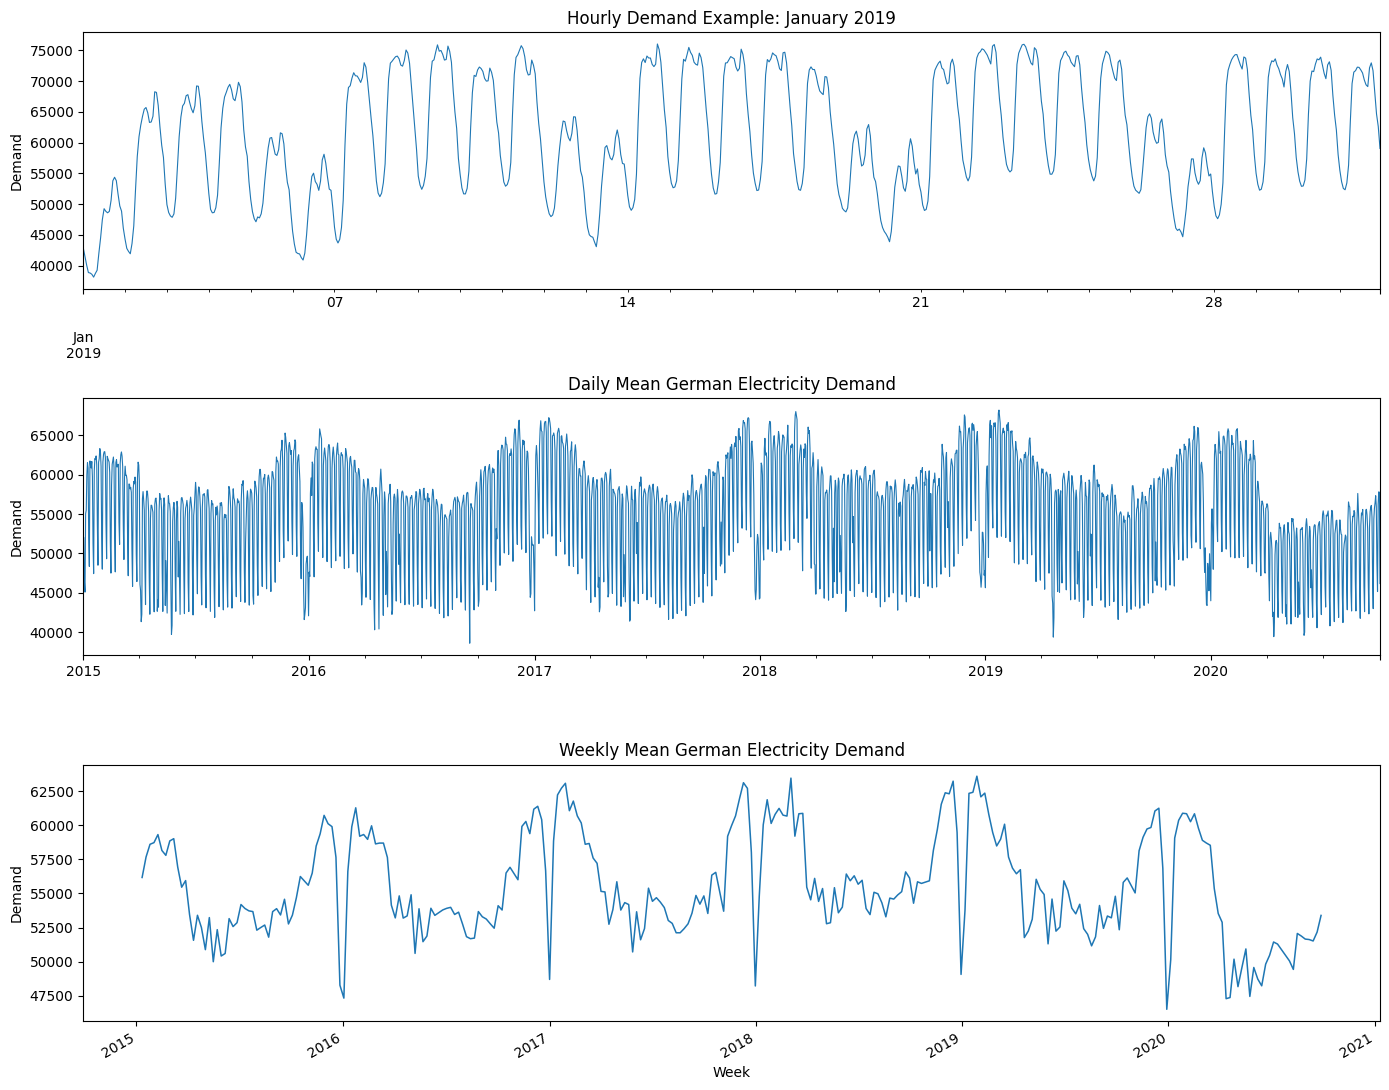

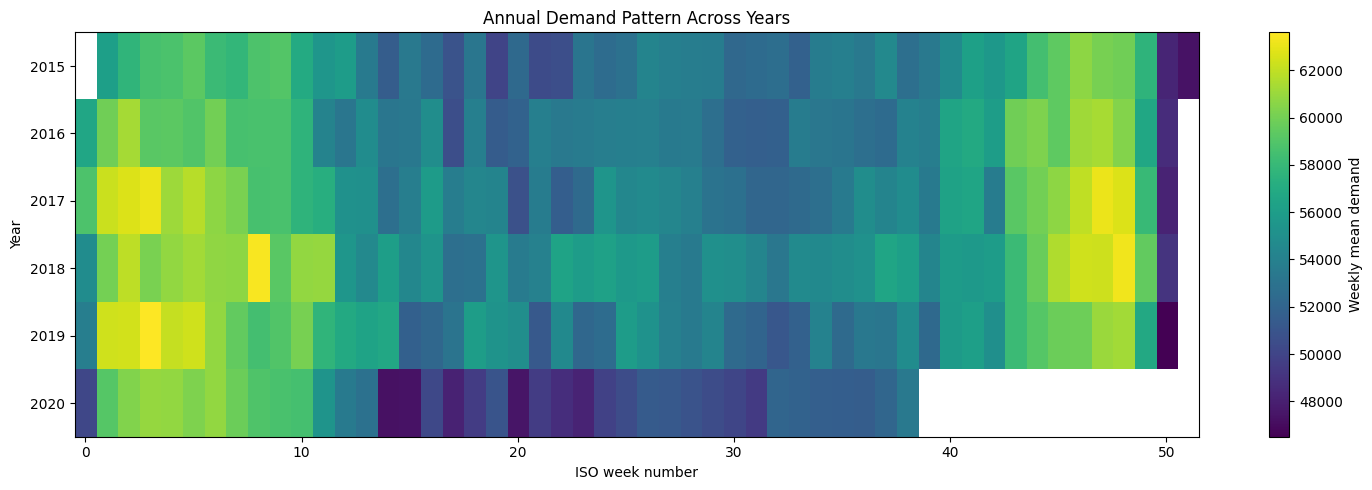

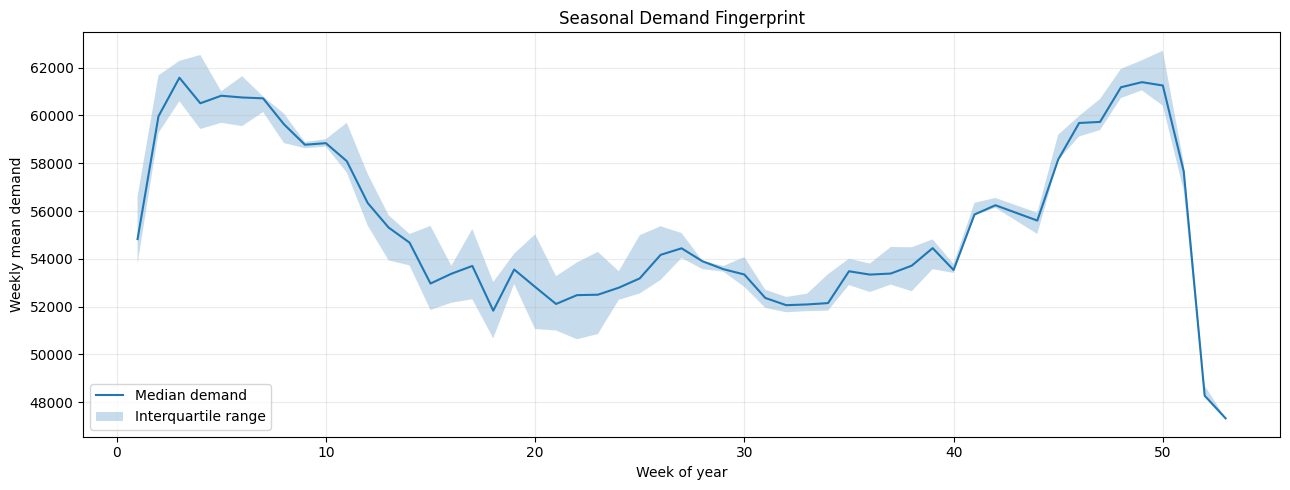

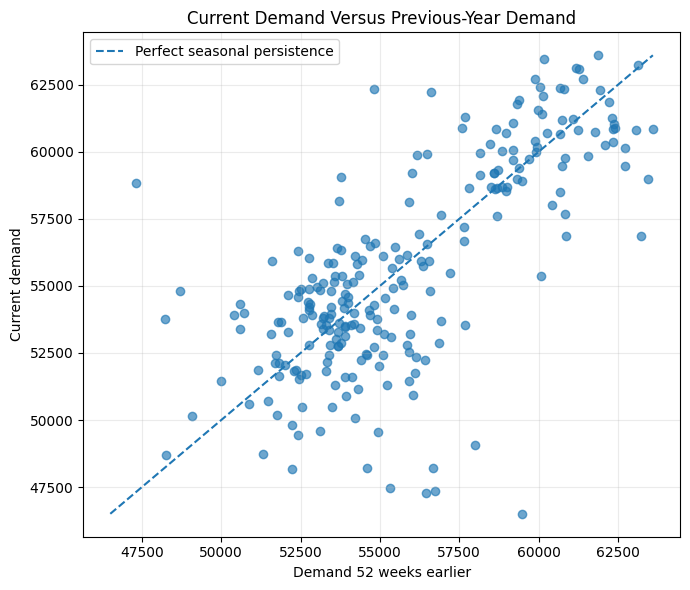

Correlation with demand 52 weeks earlier: 0.7164


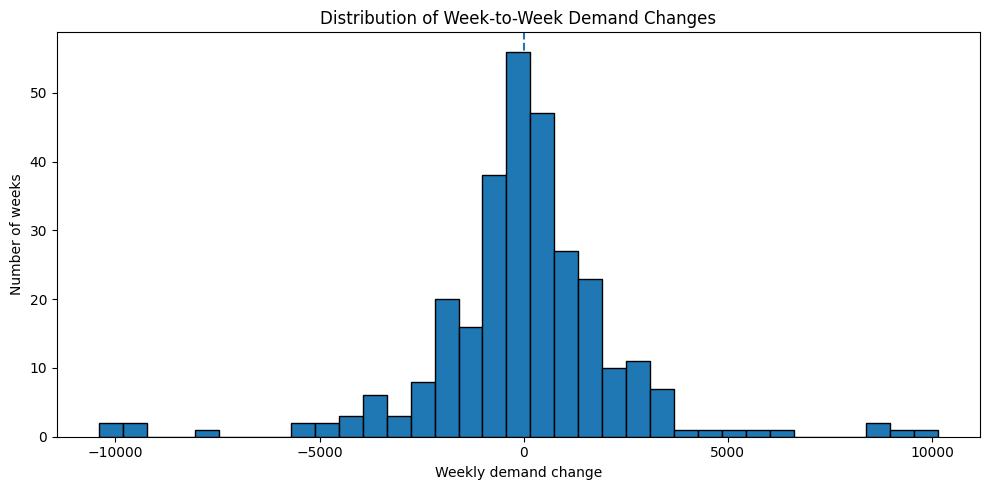


Largest weekly increases


,change
2017-01-08 00:00:00+01:00,10145.476190
2016-01-10 00:00:00+01:00,9285.345238
2020-01-12 00:00:00+01:00,8913.446429
2019-01-13 00:00:00+01:00,8555.440476
2018-01-07 00:00:00+01:00,6609.797619


Largest weekly decreases


,change
2018-12-30 00:00:00+01:00,-10403.464286
2019-12-29 00:00:00+01:00,-10350.928571
2017-12-31 00:00:00+01:00,-9794.172619
2015-12-27 00:00:00+01:00,-9381.053571
2017-01-01 00:00:00+01:00,-7967.958333



Stationarity results


,Series,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,Original weekly demand,-3.8140,0.0028,0.1629,0.10
1,First difference,-7.2103,0.0000,0.0293,0.10
2,Seasonal difference (52),-2.6963,0.0747,1.4030,0.01
3,First and seasonal difference,-10.7914,0.0000,0.0926,0.10


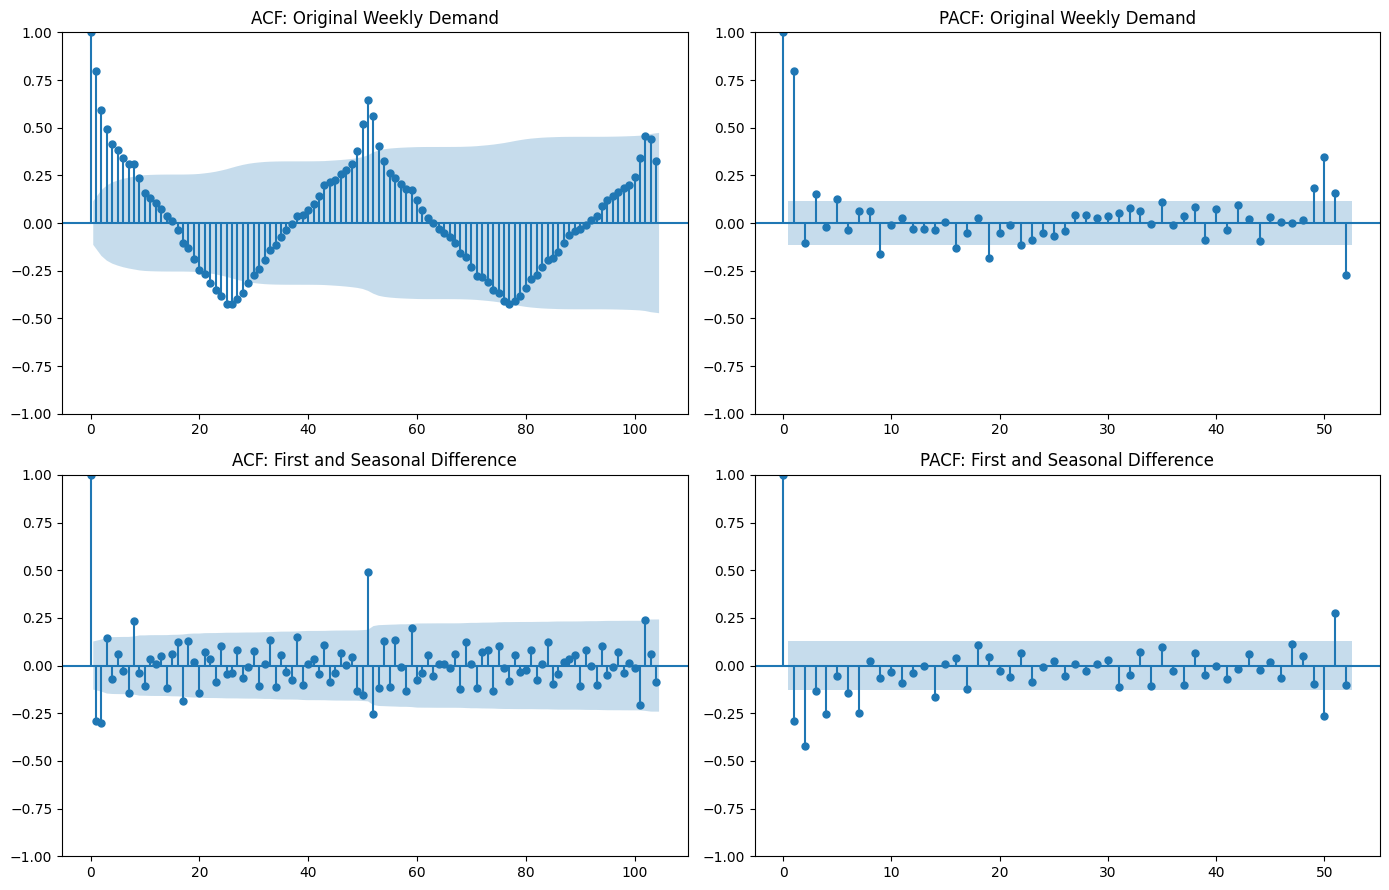

In [3]:
# ------------------------------------------------------------
# Part 1: German electricity demand preparation
# ------------------------------------------------------------

DATA_URL = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)

# Read only the header first to identify the German load column
columns = pd.read_csv(DATA_URL, nrows=0).columns.tolist()

preferred_column = "DE_load_actual_entsoe_transparency"

if preferred_column in columns:
    demand_column = preferred_column
else:
    possible_columns = [
        col for col in columns
        if col.startswith("DE_")
        and "load" in col.lower()
        and "actual" in col.lower()
    ]

    if not possible_columns:
        raise ValueError("German electricity demand column was not found.")

    demand_column = possible_columns[0]

print("Demand column selected:", demand_column)

# Load only the timestamp and German demand column
raw_data = pd.read_csv(
    DATA_URL,
    usecols=["utc_timestamp", demand_column]
)

raw_data["utc_timestamp"] = pd.to_datetime(
    raw_data["utc_timestamp"],
    utc=True
)

raw_data[demand_column] = pd.to_numeric(
    raw_data[demand_column],
    errors="coerce"
)

raw_data = (
    raw_data
    .set_index("utc_timestamp")
    .sort_index()
    .rename(columns={demand_column: "demand"})
)

# Convert UTC timestamps to German local time
raw_data.index = raw_data.index.tz_convert("Europe/Berlin")

# Keep the required period, including available October 2020 values
start_date = pd.Timestamp(
    "2015-01-01 00:00:00",
    tz="Europe/Berlin"
)

maximum_allowed_date = pd.Timestamp(
    "2020-10-31 23:59:59",
    tz="Europe/Berlin"
)

hourly_raw = raw_data.loc[
    (raw_data.index >= start_date) &
    (raw_data.index <= maximum_allowed_date),
    "demand"
].copy()

# Average duplicate timestamps if any exist
if hourly_raw.index.duplicated().any():
    hourly_raw = hourly_raw.groupby(level=0).mean()

print("\nRaw retained period")
print("Start:", hourly_raw.index.min())
print("End:", hourly_raw.index.max())
print("Observations:", len(hourly_raw))
print("Missing values:", hourly_raw.isna().sum())
print("Duplicate timestamps:", hourly_raw.index.duplicated().sum())

# Create the complete expected hourly index
expected_index = pd.date_range(
    start=hourly_raw.index.min(),
    end=hourly_raw.index.max(),
    freq="h"
)

hourly = hourly_raw.reindex(expected_index)
hourly.name = "demand"

missing_before = hourly.isna().sum()

# Interpolate isolated missing observations
hourly = hourly.interpolate(method="time")
hourly = hourly.ffill().bfill()

print("\nHourly continuity check")
print("Expected observations:", len(expected_index))
print("Missing before interpolation:", missing_before)
print("Missing after interpolation:", hourly.isna().sum())

# Daily and weekly mean electricity load
daily = hourly.resample("D").mean()
weekly_all = hourly.resample("W-SUN").mean()
weekly_counts = hourly.resample("W-SUN").count()


def expected_week_hours(week_end):
    """Expected hours in a German local calendar week."""
    week_start = (
        week_end - pd.Timedelta(days=6)
    ).normalize()

    next_week_start = (
        week_end + pd.Timedelta(days=1)
    ).normalize()

    return len(
        pd.date_range(
            start=week_start,
            end=next_week_start,
            freq="h",
            inclusive="left"
        )
    )


expected_counts = pd.Series(
    [
        expected_week_hours(date)
        for date in weekly_counts.index
    ],
    index=weekly_counts.index,
    name="expected_hours"
)

week_quality = pd.DataFrame({
    "observed_hours": weekly_counts,
    "expected_hours": expected_counts
})

week_quality["complete"] = (
    week_quality["observed_hours"] ==
    week_quality["expected_hours"]
)

# Use only complete weeks for weekly modelling
weekly = weekly_all.loc[
    week_quality["complete"]
].dropna()

print("\nAggregation summary")
print("Hourly observations:", len(hourly))
print("Daily observations:", len(daily))
print("All weekly periods:", len(weekly_all))
print("Complete modelling weeks:", len(weekly))
print("Weekly start:", weekly.index.min())
print("Weekly end:", weekly.index.max())

print("\nIncomplete boundary weeks")
display(
    week_quality.loc[
        ~week_quality["complete"]
    ]
)

# ------------------------------------------------------------
# EDA plot 1: demand at three temporal resolutions
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

hourly.loc["2019-01-01":"2019-01-31"].plot(
    ax=axes[0],
    linewidth=0.8
)
axes[0].set_title("Hourly Demand Example: January 2019")
axes[0].set_ylabel("Demand")
axes[0].set_xlabel("")

daily.plot(ax=axes[1], linewidth=0.8)
axes[1].set_title("Daily Mean German Electricity Demand")
axes[1].set_ylabel("Demand")
axes[1].set_xlabel("")

weekly.plot(ax=axes[2], linewidth=1.1)
axes[2].set_title("Weekly Mean German Electricity Demand")
axes[2].set_ylabel("Demand")
axes[2].set_xlabel("Week")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# EDA plot 2: year-week seasonal heatmap
# ------------------------------------------------------------

iso_calendar = weekly.index.isocalendar()

heatmap_data = pd.DataFrame({
    "year": iso_calendar.year.to_numpy(),
    "week": iso_calendar.week.to_numpy(),
    "demand": weekly.to_numpy()
})

heatmap_table = heatmap_data.pivot_table(
    index="year",
    columns="week",
    values="demand",
    aggfunc="mean"
)

plt.figure(figsize=(15, 5))
image = plt.imshow(
    heatmap_table,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(image, label="Weekly mean demand")
plt.yticks(
    range(len(heatmap_table.index)),
    heatmap_table.index
)
plt.xlabel("ISO week number")
plt.ylabel("Year")
plt.title("Annual Demand Pattern Across Years")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# EDA plot 3: seasonal demand fingerprint
# ------------------------------------------------------------

seasonal_data = pd.DataFrame({
    "week": iso_calendar.week.to_numpy(),
    "demand": weekly.to_numpy()
})

seasonal_summary = seasonal_data.groupby("week")["demand"].agg(
    median="median",
    lower=lambda x: x.quantile(0.25),
    upper=lambda x: x.quantile(0.75)
)

plt.figure(figsize=(13, 5))
plt.plot(
    seasonal_summary.index,
    seasonal_summary["median"],
    label="Median demand"
)
plt.fill_between(
    seasonal_summary.index,
    seasonal_summary["lower"],
    seasonal_summary["upper"],
    alpha=0.25,
    label="Interquartile range"
)

plt.title("Seasonal Demand Fingerprint")
plt.xlabel("Week of year")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# EDA plot 4: persistence against the same week last year
# ------------------------------------------------------------

persistence_data = pd.DataFrame({
    "current": weekly,
    "previous_year": weekly.shift(52)
}).dropna()

minimum_value = persistence_data.min().min()
maximum_value = persistence_data.max().max()

plt.figure(figsize=(7, 6))
plt.scatter(
    persistence_data["previous_year"],
    persistence_data["current"],
    alpha=0.65
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect seasonal persistence"
)

plt.xlabel("Demand 52 weeks earlier")
plt.ylabel("Current demand")
plt.title("Current Demand Versus Previous-Year Demand")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

seasonal_correlation = persistence_data.corr().iloc[0, 1]
print("Correlation with demand 52 weeks earlier:",
      round(seasonal_correlation, 4))

# ------------------------------------------------------------
# EDA plot 5: weekly demand-change distribution
# ------------------------------------------------------------

weekly_change = weekly.diff().dropna()

plt.figure(figsize=(10, 5))
plt.hist(weekly_change, bins=35, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Distribution of Week-to-Week Demand Changes")
plt.xlabel("Weekly demand change")
plt.ylabel("Number of weeks")
plt.tight_layout()
plt.show()

print("\nLargest weekly increases")
display(weekly_change.nlargest(5).to_frame("change"))

print("Largest weekly decreases")
display(weekly_change.nsmallest(5).to_frame("change"))

# ------------------------------------------------------------
# Stationarity tests
# ------------------------------------------------------------

def stationarity_tests(series, series_name):
    """Run ADF and KPSS tests on one transformed series."""
    clean_series = series.dropna()

    adf_result = adfuller(
        clean_series,
        autolag="AIC"
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        kpss_result = kpss(
            clean_series,
            regression="c",
            nlags="auto"
        )

    return {
        "Series": series_name,
        "ADF statistic": adf_result[0],
        "ADF p-value": adf_result[1],
        "KPSS statistic": kpss_result[0],
        "KPSS p-value": kpss_result[1]
    }


weekly_first_difference = weekly.diff()
weekly_seasonal_difference = weekly.diff(52)
weekly_combined_difference = weekly.diff().diff(52)

stationarity_results = pd.DataFrame([
    stationarity_tests(
        weekly,
        "Original weekly demand"
    ),
    stationarity_tests(
        weekly_first_difference,
        "First difference"
    ),
    stationarity_tests(
        weekly_seasonal_difference,
        "Seasonal difference (52)"
    ),
    stationarity_tests(
        weekly_combined_difference,
        "First and seasonal difference"
    )
])

print("\nStationarity results")
display(stationarity_results.round(4))

# ACF and PACF evidence
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_acf(
    weekly.dropna(),
    lags=104,
    ax=axes[0, 0]
)
axes[0, 0].set_title("ACF: Original Weekly Demand")

plot_pacf(
    weekly.dropna(),
    lags=52,
    method="ywm",
    ax=axes[0, 1]
)
axes[0, 1].set_title("PACF: Original Weekly Demand")

plot_acf(
    weekly_combined_difference.dropna(),
    lags=104,
    ax=axes[1, 0]
)
axes[1, 0].set_title(
    "ACF: First and Seasonal Difference"
)

plot_pacf(
    weekly_combined_difference.dropna(),
    lags=52,
    method="ywm",
    ax=axes[1, 1]
)
axes[1, 1].set_title(
    "PACF: First and Seasonal Difference"
)

plt.tight_layout()
plt.show()

Training period
2015-01-11 00:00:00+01:00 to 2018-09-16 00:00:00+02:00
Training weeks: 190

Testing period
2018-09-23 00:00:00+02:00 to 2020-09-27 00:00:00+02:00
Testing weeks: 104

Benchmark evaluation


,Model,MAE,RMSE,sMAPE (%),MASE,Bias,Direction accuracy (%),Peak RMSE,Underforecast weeks,Mean shortfall,Maximum shortfall,Shortfall severity (%)
0,Seasonal Naive,3095.4679,4083.2661,5.6565,2.0069,1646.0845,49.0385,2653.1104,33,2283.8768,10845.8631,1.3148
1,Drift,3635.2921,4278.7791,6.5954,2.3569,-273.5639,54.8077,7261.0008,51,3985.5002,8566.8220,3.5459
2,Naive,3720.8085,4353.4679,6.7510,2.4123,15.0489,55.7692,7139.2385,50,3853.9899,8467.8690,3.3617
3,Mean,3764.0674,4389.4842,6.8287,2.4404,561.3514,53.8462,6596.0176,47,3543.4304,7921.5665,2.9053


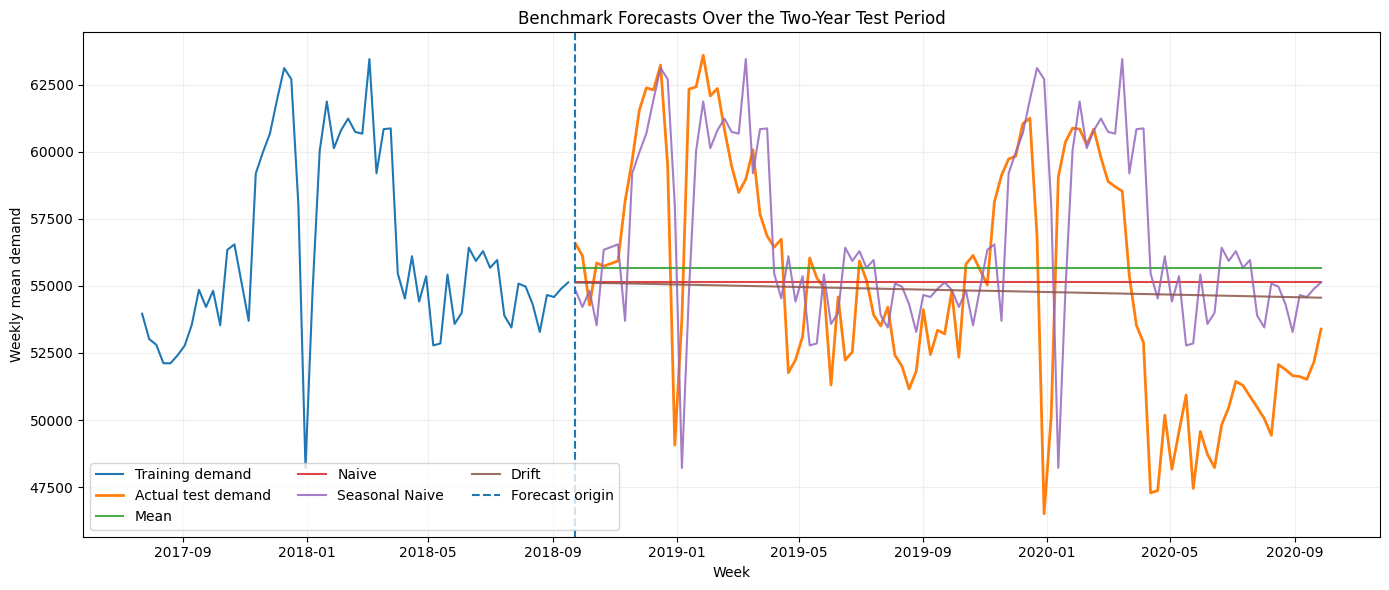

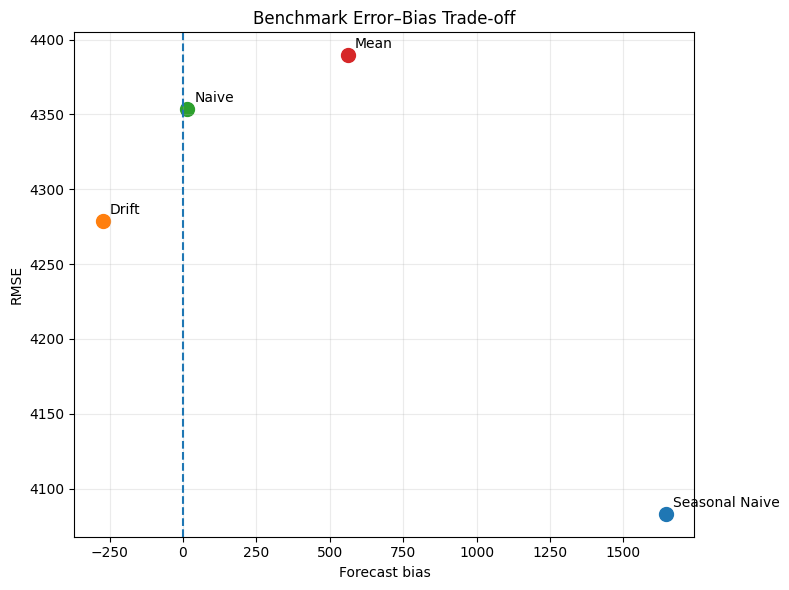

In [4]:
# ------------------------------------------------------------
# Part 2: Benchmark forecasts
# ------------------------------------------------------------

TEST_WEEKS = 104

if len(weekly) <= TEST_WEEKS + 52:
    raise ValueError("Not enough complete weeks for the required split.")

train = weekly.iloc[:-TEST_WEEKS].copy()
test = weekly.iloc[-TEST_WEEKS:].copy()

print("Training period")
print(train.index.min(), "to", train.index.max())
print("Training weeks:", len(train))

print("\nTesting period")
print(test.index.min(), "to", test.index.max())
print("Testing weeks:", len(test))

forecast_horizon = len(test)

# Mean forecast
mean_forecast = pd.Series(
    train.mean(),
    index=test.index,
    name="Mean"
)

# Naive forecast
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index,
    name="Naive"
)

# Seasonal-naive forecast
seasonal_pattern = train.iloc[-52:].to_numpy()

seasonal_naive_values = np.resize(
    seasonal_pattern,
    forecast_horizon
)

seasonal_naive_forecast = pd.Series(
    seasonal_naive_values,
    index=test.index,
    name="Seasonal Naive"
)

# Drift forecast
drift_per_week = (
    train.iloc[-1] - train.iloc[0]
) / (len(train) - 1)

drift_values = (
    train.iloc[-1] +
    drift_per_week *
    np.arange(1, forecast_horizon + 1)
)

drift_forecast = pd.Series(
    drift_values,
    index=test.index,
    name="Drift"
)

# Store forecasts for later comparison
model_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal Naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}

model_intervals = {}

benchmark_rows = []

for model_name, forecast in model_forecasts.items():
    benchmark_rows.append(
        evaluate_forecast(
            model_name=model_name,
            actual=test,
            forecast=forecast,
            training_series=train,
            last_training_value=train.iloc[-1]
        )
    )

benchmark_metrics = (
    pd.DataFrame(benchmark_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("\nBenchmark evaluation")
display(benchmark_metrics.round(4))

# Forecast comparison
plt.figure(figsize=(14, 6))

plt.plot(
    train.index[-60:],
    train.iloc[-60:],
    label="Training demand"
)

plt.plot(
    test.index,
    test,
    label="Actual test demand",
    linewidth=2
)

for model_name, forecast in model_forecasts.items():
    plt.plot(
        forecast.index,
        forecast,
        label=model_name,
        alpha=0.85
    )

plt.axvline(
    test.index.min(),
    linestyle="--",
    label="Forecast origin"
)

plt.title("Benchmark Forecasts Over the Two-Year Test Period")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend(ncol=3)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Meaningful benchmark comparison:
# error size versus systematic bias
plt.figure(figsize=(8, 6))

for _, row in benchmark_metrics.iterrows():
    plt.scatter(
        row["Bias"],
        row["RMSE"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (row["Bias"], row["RMSE"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axvline(0, linestyle="--")
plt.xlabel("Forecast bias")
plt.ylabel("RMSE")
plt.title("Benchmark Error–Bias Trade-off")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Stage 1: testing 147 required non-seasonal combinations
Completed 20/147
Completed 40/147
Completed 60/147
Completed 80/147
Completed 100/147
Completed 120/147
Completed 140/147

Successful Stage 1 models: 147

Best Stage 1 candidates


,order,seasonal_order,AIC,BIC,converged
0,"(4, 2, 6)","(1, 1, 1, 52)",1405.784239,1436.253709,False
1,"(5, 2, 6)","(1, 1, 1, 52)",1408.098886,1440.912162,False
2,"(6, 2, 6)","(1, 1, 1, 52)",1410.094869,1445.251950,False
3,"(2, 2, 6)","(1, 1, 1, 52)",1410.863887,1436.645746,False
4,"(3, 2, 6)","(1, 1, 1, 52)",1412.053436,1440.179101,False
5,"(5, 1, 6)","(1, 1, 1, 52)",1420.133524,1453.127448,False
6,"(3, 1, 6)","(1, 1, 1, 52)",1420.212149,1448.492655,False
7,"(4, 1, 6)","(1, 1, 1, 52)",1420.485400,1451.122615,False
8,"(1, 2, 6)","(1, 1, 1, 52)",1420.757746,1444.195800,False
9,"(2, 1, 6)","(1, 1, 1, 52)",1421.046331,1446.970128,True



Stage 2: seasonal refinement

Best seasonal refinements


,order,seasonal_order,AIC,BIC,converged
0,"(0, 1, 6)","(0, 1, 1, 52)",1418.455686,1437.309356,True
1,"(2, 1, 6)","(1, 1, 1, 52)",1421.046331,1446.970128,True
2,"(2, 1, 6)","(0, 1, 1, 52)",1423.304266,1446.871354,True
3,"(1, 1, 6)","(0, 1, 1, 52)",1423.480632,1444.691012,True
4,"(1, 1, 6)","(1, 1, 1, 52)",1423.860931,1447.428019,True
5,"(0, 1, 6)","(1, 1, 1, 52)",1424.681781,1445.892160,True
6,"(2, 1, 6)","(1, 1, 0, 52)",1512.087758,1536.276164,True
7,"(1, 1, 6)","(1, 1, 0, 52)",1536.103002,1557.980353,True
8,"(0, 1, 6)","(1, 1, 0, 52)",1552.754364,1572.295574,True
9,"(2, 1, 6)","(0, 1, 0, 52)",2367.393541,2393.201351,True


Selected SARIMA order: (0, 1, 6)
Selected seasonal order: (0, 1, 1, 52)
Selected AIC: 1418.455685528659

SARIMA test performance


,Model,MAE,RMSE,sMAPE (%),MASE,Bias,Direction accuracy (%),Peak RMSE,Underforecast weeks,Mean shortfall,Maximum shortfall,Shortfall severity (%)
0,SARIMA,3508.5241,4578.9298,6.3511,2.2747,2598.3753,48.0769,2807.5257,25,1893.1095,8395.2919,0.8256


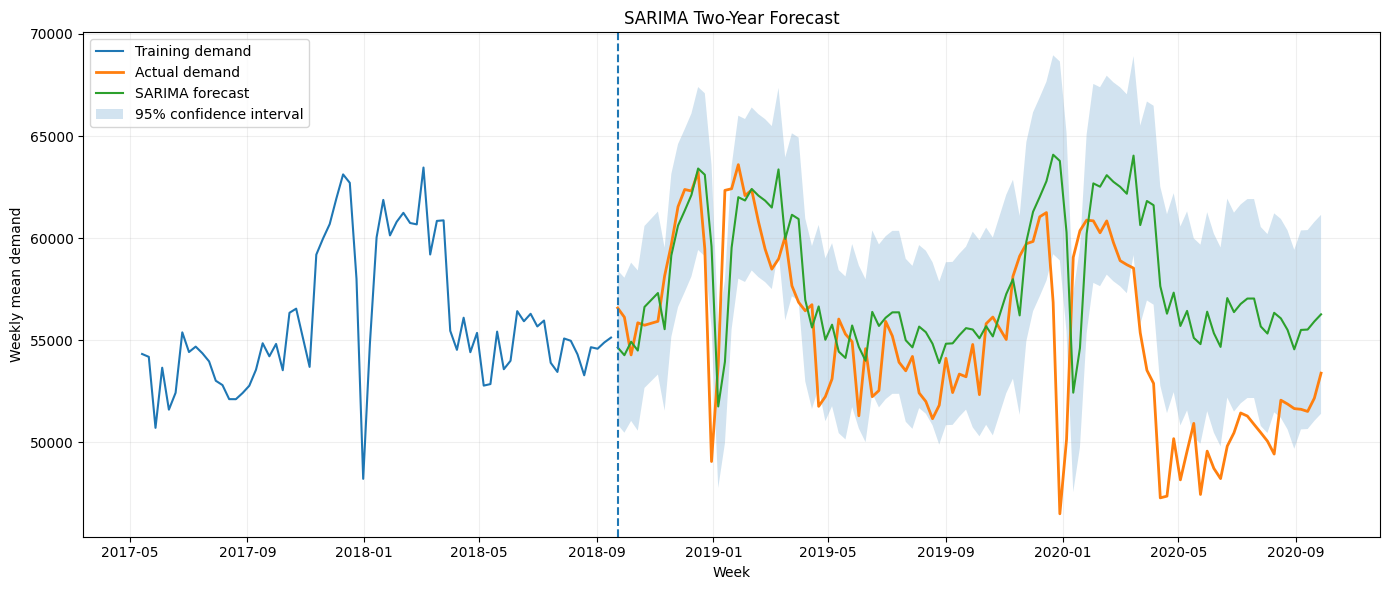


Ljung-Box residual test


,lb_stat,lb_pvalue
12,21.8934,0.0387
26,25.7541,0.4767
52,82.1859,0.0048


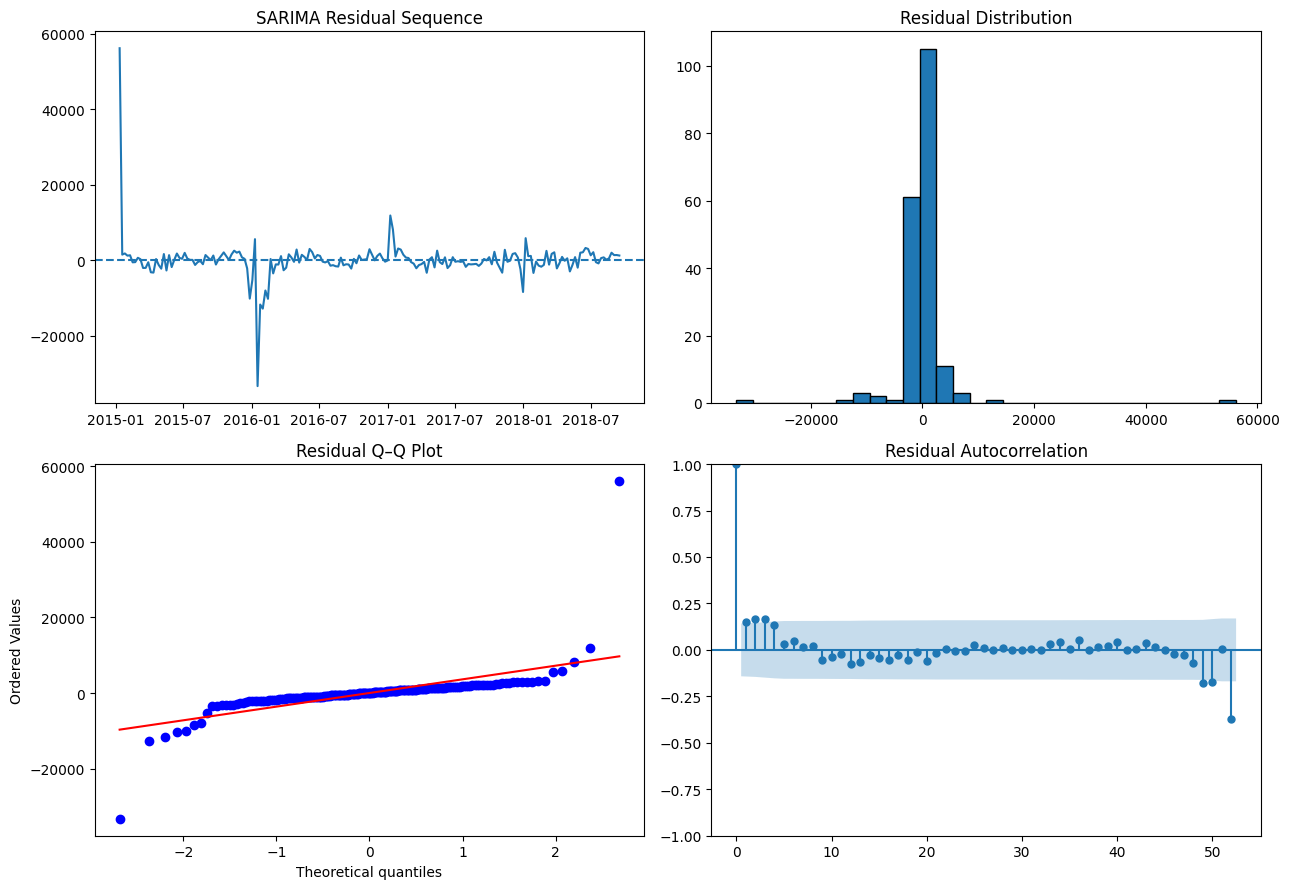

In [5]:
# ------------------------------------------------------------
# Part 3: SARIMA parameter search
# ------------------------------------------------------------

def fit_sarima_candidate(
    training_data,
    order,
    seasonal_order,
    max_iterations=60
):
    """Fit one SARIMA candidate and return model information."""
    try:
        model = SARIMAX(
            training_data,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False,
            maxiter=max_iterations
        )

        converged = fitted_model.mle_retvals.get(
            "converged",
            True
        )

        return {
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "converged": converged,
            "model": fitted_model
        }

    except Exception:
        return None


# The required full non-seasonal search:
# p = 0 to 6, d = 0 to 2, q = 0 to 6
base_seasonal_order = (1, 1, 1, 52)

stage_one_results = []

total_combinations = 7 * 3 * 7
completed = 0

print("Stage 1: testing", total_combinations,
      "required non-seasonal combinations")

for p, d, q in product(
    range(0, 7),
    range(0, 3),
    range(0, 7)
):
    result = fit_sarima_candidate(
        training_data=train,
        order=(p, d, q),
        seasonal_order=base_seasonal_order,
        max_iterations=60
    )

    completed += 1

    if result is not None:
        stage_one_results.append({
            key: value
            for key, value in result.items()
            if key != "model"
        })

    if completed % 20 == 0:
        print(
            f"Completed {completed}/{total_combinations}"
        )

stage_one_table = (
    pd.DataFrame(stage_one_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("\nSuccessful Stage 1 models:",
      len(stage_one_table))

print("\nBest Stage 1 candidates")
display(stage_one_table.head(10))

# Refine seasonal parameters only for the strongest orders
top_orders = (
    stage_one_table
    .loc[stage_one_table["converged"], "order"]
    .head(3)
    .tolist()
)

if len(top_orders) == 0:
    top_orders = stage_one_table["order"].head(3).tolist()

seasonal_candidates = list(
    product([0, 1], [0, 1], [0, 1])
)

stage_two_results = []

print("\nStage 2: seasonal refinement")

for order in top_orders:
    for P, D, Q in seasonal_candidates:
        seasonal_order = (P, D, Q, 52)

        result = fit_sarima_candidate(
            training_data=train,
            order=order,
            seasonal_order=seasonal_order,
            max_iterations=100
        )

        if result is not None:
            stage_two_results.append({
                key: value
                for key, value in result.items()
                if key != "model"
            })

stage_two_table = (
    pd.DataFrame(stage_two_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("\nBest seasonal refinements")
display(stage_two_table.head(10))

# Choose the lowest-AIC converged candidate
valid_stage_two = stage_two_table.loc[
    stage_two_table["converged"]
]

if len(valid_stage_two) > 0:
    selected_row = valid_stage_two.iloc[0]
else:
    selected_row = stage_two_table.iloc[0]

best_order = tuple(selected_row["order"])
best_seasonal_order = tuple(
    selected_row["seasonal_order"]
)

print("Selected SARIMA order:", best_order)
print("Selected seasonal order:",
      best_seasonal_order)
print("Selected AIC:", selected_row["AIC"])

# Refit the selected model with more iterations
sarima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(
    disp=False,
    maxiter=200
)

# Two-year forecast
sarima_prediction = sarima_result.get_forecast(
    steps=len(test)
)

sarima_forecast = pd.Series(
    sarima_prediction.predicted_mean.to_numpy(),
    index=test.index,
    name="SARIMA"
)

sarima_confidence = sarima_prediction.conf_int(
    alpha=0.05
)

sarima_lower = pd.Series(
    sarima_confidence.iloc[:, 0].to_numpy(),
    index=test.index
)

sarima_upper = pd.Series(
    sarima_confidence.iloc[:, 1].to_numpy(),
    index=test.index
)

model_forecasts["SARIMA"] = sarima_forecast
model_intervals["SARIMA"] = (
    sarima_lower,
    sarima_upper
)

sarima_metrics = evaluate_forecast(
    model_name="SARIMA",
    actual=test,
    forecast=sarima_forecast,
    training_series=train,
    last_training_value=train.iloc[-1]
)

print("\nSARIMA test performance")
display(
    pd.DataFrame([sarima_metrics]).round(4)
)

# Forecast and confidence interval
plt.figure(figsize=(14, 6))

plt.plot(
    train.index[-70:],
    train.iloc[-70:],
    label="Training demand"
)

plt.plot(
    test.index,
    test,
    label="Actual demand",
    linewidth=2
)

plt.plot(
    test.index,
    sarima_forecast,
    label="SARIMA forecast"
)

plt.fill_between(
    test.index,
    sarima_lower,
    sarima_upper,
    alpha=0.20,
    label="95% confidence interval"
)

plt.axvline(test.index.min(), linestyle="--")
plt.title("SARIMA Two-Year Forecast")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Residual diagnostics
# ------------------------------------------------------------

sarima_residuals = pd.Series(
    sarima_result.resid
).dropna()

ljung_box_lags = [
    lag for lag in [12, 26, 52]
    if lag < len(sarima_residuals)
]

ljung_box_results = acorr_ljungbox(
    sarima_residuals,
    lags=ljung_box_lags,
    return_df=True
)

print("\nLjung-Box residual test")
display(ljung_box_results.round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(sarima_residuals)
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_title("SARIMA Residual Sequence")

axes[0, 1].hist(
    sarima_residuals,
    bins=30,
    edgecolor="black"
)
axes[0, 1].set_title("Residual Distribution")

stats.probplot(
    sarima_residuals,
    dist="norm",
    plot=axes[1, 0]
)
axes[1, 0].set_title("Residual Q–Q Plot")

plot_acf(
    sarima_residuals,
    lags=min(52, len(sarima_residuals) - 1),
    ax=axes[1, 1]
)
axes[1, 1].set_title("Residual Autocorrelation")

plt.tight_layout()
plt.show()

# Save search results for later export
sarima_search_results = pd.concat(
    [
        stage_one_table.assign(stage="Non-seasonal search"),
        stage_two_table.assign(stage="Seasonal refinement")
    ],
    ignore_index=True
)

Weather period: 2015-01-01 00:00:00+01:00 to 2020-10-01 00:00:00+02:00
Merged weekly shape: (294, 12)
Missing values: 0


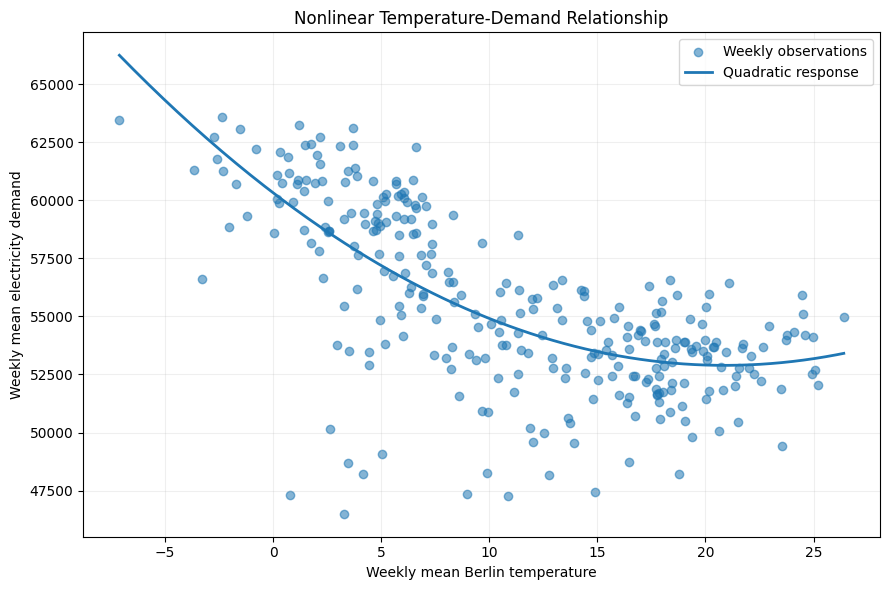

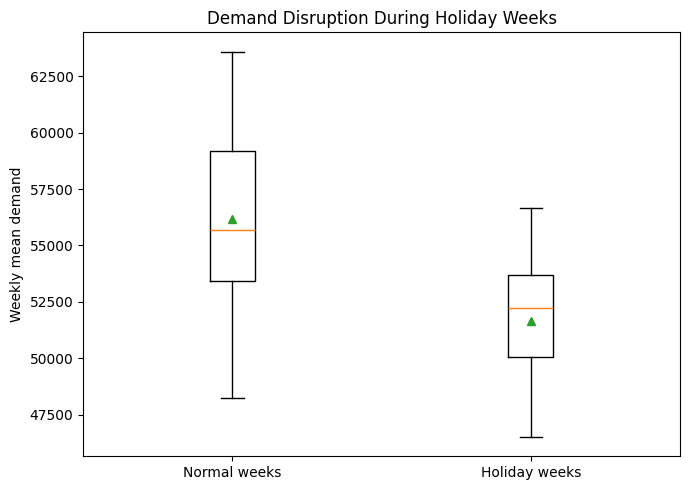


Conditional forecast comparison


,Model,MAE,RMSE,sMAPE (%),MASE,Bias,Direction accuracy (%),Peak RMSE,Underforecast weeks,Mean shortfall,Maximum shortfall,Shortfall severity (%)
0,SARIMA,3508.5241,4578.9298,6.3511,2.2747,2598.3753,48.0769,2807.5257,25,1893.1095,8395.2919,0.8256
1,SARIMAX Temperature,3529.7408,4604.7944,6.3891,2.2885,2649.2611,48.0769,2763.0902,24,1907.7059,8282.9904,0.7987
2,SARIMAX Temperature + Holidays,5278.9062,6951.1819,9.3145,3.4225,5029.9008,56.7308,1367.2833,14,924.8772,3387.8630,0.2259


Observed test-period temperature is used. These SARIMAX results are conditional forecasts.


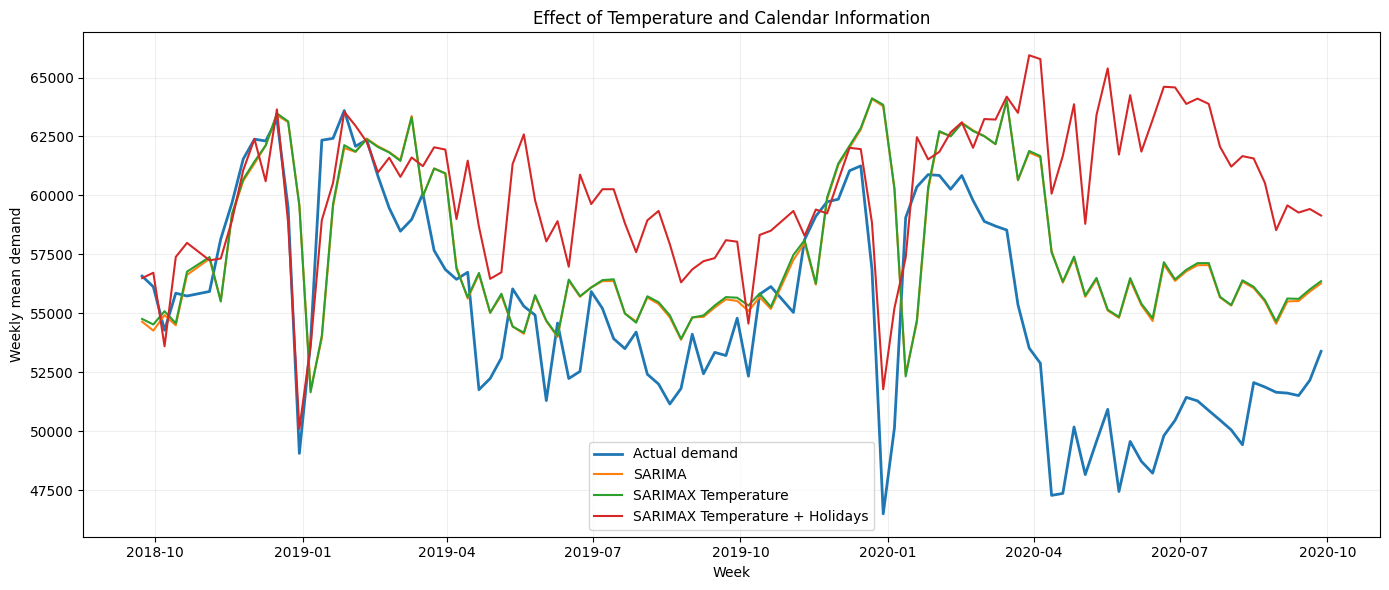

In [8]:
# ------------------------------------------------------------
# Part 4: Berlin weather and calendar variables

# ------------------------------------------------------------

import requests
import holidays
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ------------------------------------------------------------
# 4.1 Download Berlin weather data from Open-Meteo
# ------------------------------------------------------------

weather_start = hourly.index.min().date().isoformat()
weather_end = hourly.index.max().date().isoformat()

weather_url = "https://archive-api.open-meteo.com/v1/archive"

weather_parameters = {
    "latitude": 52.52,
    "longitude": 13.41,
    "start_date": weather_start,
    "end_date": weather_end,
    "daily": [
        "temperature_2m_mean",
        "temperature_2m_min",
        "temperature_2m_max"
    ],
    "timezone": "Europe/Berlin"
}

weather_response = requests.get(
    weather_url,
    params=weather_parameters,
    timeout=120
)

weather_response.raise_for_status()
weather_json = weather_response.json()

weather_daily = pd.DataFrame({
    "date": pd.to_datetime(weather_json["daily"]["time"]),
    "temp_mean": weather_json["daily"]["temperature_2m_mean"],
    "temp_min": weather_json["daily"]["temperature_2m_min"],
    "temp_max": weather_json["daily"]["temperature_2m_max"]
})

# Localise daily dates to Berlin timezone
weather_daily["date"] = weather_daily["date"].dt.tz_localize("Europe/Berlin")
weather_daily = weather_daily.set_index("date")

# ------------------------------------------------------------
# 4.2 Create German calendar and holiday variables
# ------------------------------------------------------------

german_holidays = holidays.country_holidays(
    "DE",
    years=range(
        hourly.index.min().year,
        hourly.index.max().year + 1
    )
)

weather_daily["holiday_name"] = [
    german_holidays.get(date.date(), "")
    for date in weather_daily.index
]

weather_daily["is_holiday"] = (
    weather_daily["holiday_name"] != ""
).astype(int)

weather_daily["working_day"] = (
    (weather_daily.index.weekday < 5) &
    (weather_daily["is_holiday"] == 0)
).astype(int)

weather_daily["christmas_new_year"] = (
    (
        (weather_daily.index.month == 12) &
        (weather_daily.index.day >= 20)
    ) |
    (
        (weather_daily.index.month == 1) &
        (weather_daily.index.day <= 7)
    )
).astype(int)

weather_daily["easter_period"] = (
    weather_daily["holiday_name"]
    .astype(str)
    .str.contains(
        "Easter|Good Friday|Karfreitag|Oster",
        case=False,
        regex=True
    )
    .astype(int)
)

# Heating degree days and cooling degree days
weather_daily["hdd"] = np.maximum(
    18 - weather_daily["temp_mean"],
    0
)

weather_daily["cdd"] = np.maximum(
    weather_daily["temp_mean"] - 22,
    0
)

# ------------------------------------------------------------
# 4.3 Convert daily weather and calendar data to weekly level
# ------------------------------------------------------------

weather_weekly = weather_daily.resample("W-SUN").agg({
    "temp_mean": "mean",
    "temp_min": "min",
    "temp_max": "max",
    "hdd": "sum",
    "cdd": "sum",
    "is_holiday": "sum",
    "working_day": "sum",
    "christmas_new_year": "max",
    "easter_period": "max"
})

weather_weekly = weather_weekly.rename(
    columns={
        "is_holiday": "holiday_days",
        "working_day": "working_days"
    }
)

# Seasonal calendar encoding using sine and cosine
iso_week = weather_weekly.index.isocalendar().week.astype(int)

weather_weekly["week_sin"] = np.sin(
    2 * np.pi * iso_week / 52
)

weather_weekly["week_cos"] = np.cos(
    2 * np.pi * iso_week / 52
)

# Align weather data exactly with weekly demand index
weather_weekly = weather_weekly.reindex(weekly.index)

# Fill any boundary gaps after alignment
weather_weekly = (
    weather_weekly
    .interpolate()
    .ffill()
    .bfill()
)

# Merge weekly demand with weather and calendar features
weekly_exog = pd.concat(
    [
        weekly.rename("demand"),
        weather_weekly
    ],
    axis=1
)

print("Weather period:",
      weather_daily.index.min(),
      "to",
      weather_daily.index.max())

print("Merged weekly shape:", weekly_exog.shape)
print("Missing values:", weekly_exog.isna().sum().sum())

# ------------------------------------------------------------
# 4.4 Plot nonlinear temperature-demand relationship
# ------------------------------------------------------------

temperature_x = weekly_exog["temp_mean"].astype(float)
demand_y = weekly_exog["demand"].astype(float)

# Correct argument is deg, not degree
curve_parameters = np.polyfit(
    temperature_x,
    demand_y,
    deg=2
)

temperature_line = np.linspace(
    temperature_x.min(),
    temperature_x.max(),
    200
)

demand_curve = np.polyval(
    curve_parameters,
    temperature_line
)

plt.figure(figsize=(9, 6))

plt.scatter(
    temperature_x,
    demand_y,
    alpha=0.55,
    label="Weekly observations"
)

plt.plot(
    temperature_line,
    demand_curve,
    linewidth=2,
    label="Quadratic response"
)

plt.xlabel("Weekly mean Berlin temperature")
plt.ylabel("Weekly mean electricity demand")
plt.title("Nonlinear Temperature-Demand Relationship")
plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4.5 Compare holiday weeks and normal weeks
# ------------------------------------------------------------

normal_weeks = weekly_exog.loc[
    weekly_exog["holiday_days"] == 0,
    "demand"
]

holiday_weeks = weekly_exog.loc[
    weekly_exog["holiday_days"] > 0,
    "demand"
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [normal_weeks, holiday_weeks],
    labels=["Normal weeks", "Holiday weeks"],
    showmeans=True
)

plt.ylabel("Weekly mean demand")
plt.title("Demand Disruption During Holiday Weeks")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4.6 Prepare train and test exogenous variables
# ------------------------------------------------------------

train_exog = weekly_exog.loc[train.index]
test_exog = weekly_exog.loc[test.index]

def fit_exogenous_sarimax(model_name, feature_columns):
    """
    Fit SARIMAX using selected weather and calendar variables.
    Exogenous variables are scaled using only training data.
    """

    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(
        train_exog[feature_columns]
    )

    test_scaled = scaler.transform(
        test_exog[feature_columns]
    )

    model = SARIMAX(
        train,
        exog=train_scaled,
        order=best_order,
        seasonal_order=best_seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=200
    )

    prediction = result.get_forecast(
        steps=len(test),
        exog=test_scaled
    )

    forecast = pd.Series(
        prediction.predicted_mean.to_numpy(),
        index=test.index,
        name=model_name
    )

    confidence = prediction.conf_int(alpha=0.05)

    lower = pd.Series(
        confidence.iloc[:, 0].to_numpy(),
        index=test.index
    )

    upper = pd.Series(
        confidence.iloc[:, 1].to_numpy(),
        index=test.index
    )

    return result, forecast, lower, upper

# ------------------------------------------------------------
# 4.7 Fit SARIMAX models with different external information
# ------------------------------------------------------------

temperature_features = [
    "temp_mean"
]

temperature_holiday_features = [
    "temp_mean",
    "hdd",
    "cdd",
    "holiday_days",
    "working_days",
    "christmas_new_year",
    "easter_period",
    "week_sin",
    "week_cos"
]

sarimax_t_result, sarimax_t_forecast, sarimax_t_lower, sarimax_t_upper = (
    fit_exogenous_sarimax(
        "SARIMAX Temperature",
        temperature_features
    )
)

sarimax_th_result, sarimax_th_forecast, sarimax_th_lower, sarimax_th_upper = (
    fit_exogenous_sarimax(
        "SARIMAX Temperature + Holidays",
        temperature_holiday_features
    )
)

model_forecasts["SARIMAX Temperature"] = sarimax_t_forecast
model_forecasts["SARIMAX Temperature + Holidays"] = sarimax_th_forecast

model_intervals["SARIMAX Temperature"] = (
    sarimax_t_lower,
    sarimax_t_upper
)

model_intervals["SARIMAX Temperature + Holidays"] = (
    sarimax_th_lower,
    sarimax_th_upper
)

# ------------------------------------------------------------
# 4.8 Evaluate SARIMA against SARIMAX models
# ------------------------------------------------------------

sarimax_comparison_rows = []

for model_name in [
    "SARIMA",
    "SARIMAX Temperature",
    "SARIMAX Temperature + Holidays"
]:
    sarimax_comparison_rows.append(
        evaluate_forecast(
            model_name,
            test,
            model_forecasts[model_name],
            train,
            train.iloc[-1]
        )
    )

sarimax_comparison = (
    pd.DataFrame(sarimax_comparison_rows)
    .sort_values("RMSE")
)

print("\nConditional forecast comparison")
display(sarimax_comparison.round(4))

print(
    "Observed test-period temperature is used. "
    "These SARIMAX results are conditional forecasts."
)

# ------------------------------------------------------------
# 4.9 Plot SARIMA and SARIMAX forecasts
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test,
    label="Actual demand",
    linewidth=2
)

plt.plot(
    test.index,
    sarima_forecast,
    label="SARIMA"
)

plt.plot(
    test.index,
    sarimax_t_forecast,
    label="SARIMAX Temperature"
)

plt.plot(
    test.index,
    sarimax_th_forecast,
    label="SARIMAX Temperature + Holidays"
)

plt.title("Effect of Temperature and Calendar Information")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

CatBoost training shape: (138, 26)
CatBoost testing shape: (104, 26)
Candidate 1/12 completed
Candidate 2/12 completed
Candidate 3/12 completed
Candidate 4/12 completed
Candidate 5/12 completed
Candidate 6/12 completed
Candidate 7/12 completed
Candidate 8/12 completed
Candidate 9/12 completed
Candidate 10/12 completed
Candidate 11/12 completed
Candidate 12/12 completed

Best CatBoost tuning results


,candidate,mean_validation_rmse,subsample,random_strength,learning_rate,l2_leaf_reg,iterations,depth
0,6,1703.2584,1.00,1.0,0.10,3,300,6
1,9,1745.0207,0.90,2.0,0.10,5,500,4
2,8,1773.5386,0.75,0.5,0.02,3,500,4
3,1,1794.7381,0.75,0.5,0.05,10,800,6
4,2,1804.8837,0.90,1.0,0.05,10,500,4


Selected CatBoost parameters
{'iterations': 300, 'depth': 6, 'learning_rate': np.float64(0.1), 'l2_leaf_reg': np.float64(3.0), 'random_strength': np.float64(1.0), 'subsample': np.float64(1.0)}

CatBoost test results


,Model,MAE,RMSE,sMAPE (%),MASE,Bias,Direction accuracy (%),Peak RMSE,Underforecast weeks,Mean shortfall,Maximum shortfall,Shortfall severity (%)
0,CatBoost,1881.206,2497.1856,3.5,1.2197,1199.0358,61.5385,1618.3119,35,1013.5101,3722.9054,0.6188


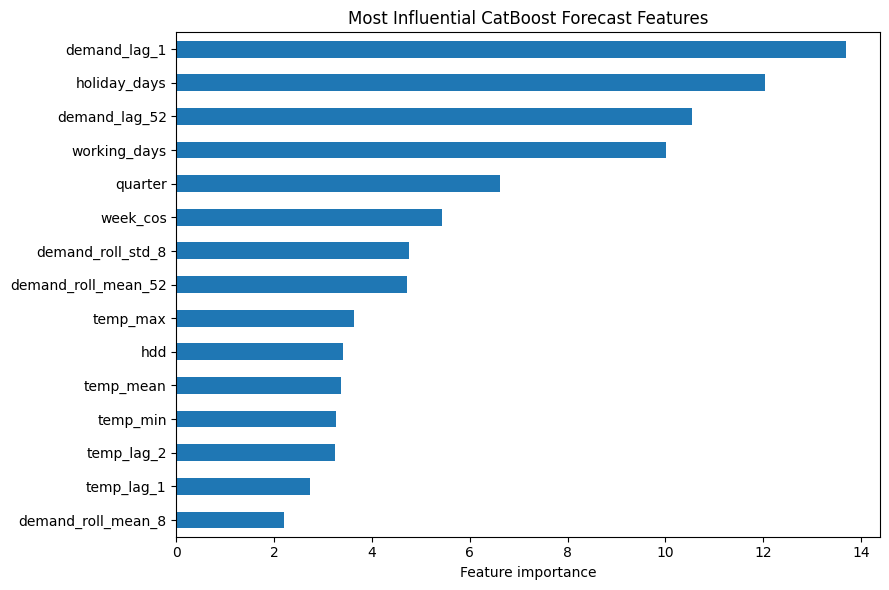

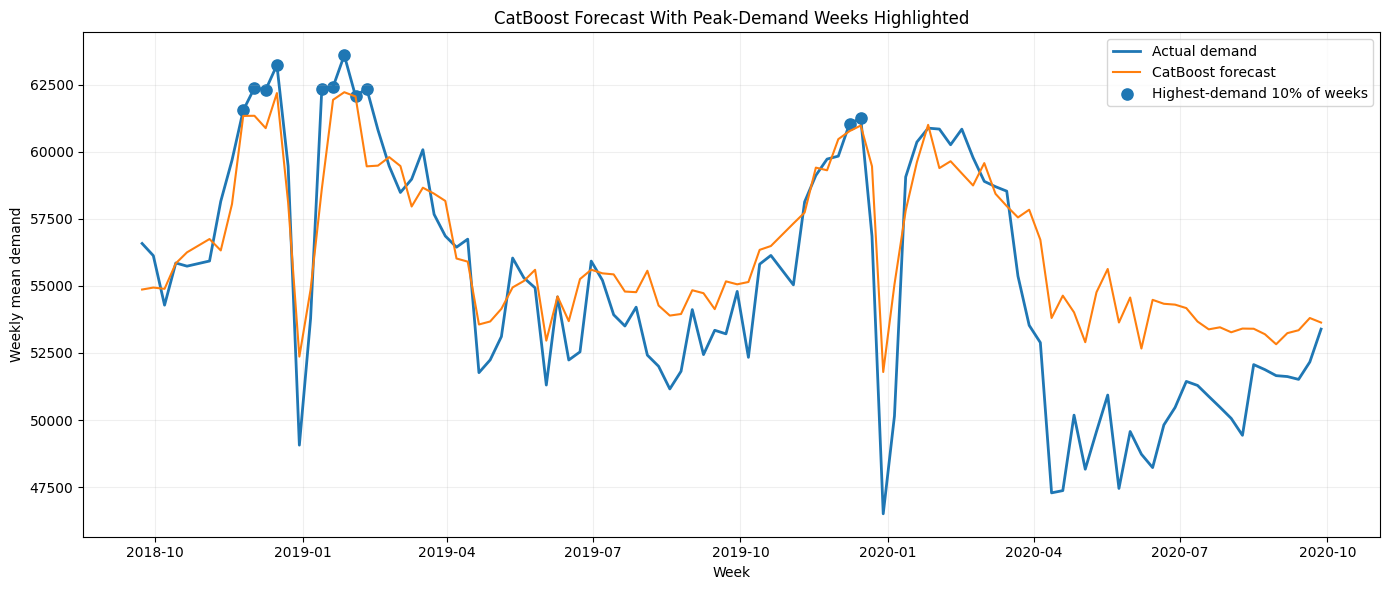

In [9]:
# ------------------------------------------------------------
# Part 5: Leakage-safe CatBoost features
# ------------------------------------------------------------

catboost_data = weekly_exog.copy()

# Historical demand features
for lag in [1, 2, 4, 52]:
    catboost_data[f"demand_lag_{lag}"] = (
        catboost_data["demand"].shift(lag)
    )

# Rolling demand features use only earlier observations
for window in [4, 8, 52]:
    catboost_data[f"demand_roll_mean_{window}"] = (
        catboost_data["demand"]
        .shift(1)
        .rolling(window)
        .mean()
    )

catboost_data["demand_roll_std_8"] = (
    catboost_data["demand"]
    .shift(1)
    .rolling(8)
    .std()
)

# Lagged temperature information
for lag in [1, 2, 4]:
    catboost_data[f"temp_lag_{lag}"] = (
        catboost_data["temp_mean"].shift(lag)
    )

catboost_data["temp_roll_mean_4"] = (
    catboost_data["temp_mean"]
    .shift(1)
    .rolling(4)
    .mean()
)

# Calendar information
catboost_data["month"] = (
    catboost_data.index.month.astype(str)
)

catboost_data["quarter"] = (
    catboost_data.index.quarter.astype(str)
)

catboost_data["week_of_year"] = (
    catboost_data.index
    .isocalendar()
    .week
    .astype(str)
)

catboost_data = catboost_data.dropna().copy()

target_column = "demand"

feature_columns = [
    column for column in catboost_data.columns
    if column != target_column
]

categorical_columns = [
    "month",
    "quarter",
    "week_of_year"
]

cat_train_data = catboost_data.loc[
    catboost_data.index < test.index.min()
]

cat_test_data = catboost_data.loc[
    catboost_data.index.isin(test.index)
]

X_train_cat = cat_train_data[feature_columns]
y_train_cat = cat_train_data[target_column]

X_test_cat = cat_test_data[feature_columns]
y_test_cat = cat_test_data[target_column]

print("CatBoost training shape:", X_train_cat.shape)
print("CatBoost testing shape:", X_test_cat.shape)

# ------------------------------------------------------------
# Time-series hyperparameter tuning
# ------------------------------------------------------------

parameter_space = {
    "iterations": [300, 500, 800],
    "depth": [4, 6, 8],
    "learning_rate": [0.02, 0.05, 0.10],
    "l2_leaf_reg": [3, 5, 10],
    "random_strength": [0.5, 1.0, 2.0],
    "subsample": [0.75, 0.90, 1.0]
}

parameter_candidates = list(
    ParameterSampler(
        parameter_space,
        n_iter=12,
        random_state=SEED
    )
)

time_series_cv = TimeSeriesSplit(n_splits=3)
tuning_results = []

for candidate_number, parameters in enumerate(
    parameter_candidates,
    start=1
):
    fold_rmse = []

    for train_positions, validation_positions in (
        time_series_cv.split(X_train_cat)
    ):
        X_fold_train = X_train_cat.iloc[
            train_positions
        ]

        y_fold_train = y_train_cat.iloc[
            train_positions
        ]

        X_fold_validation = X_train_cat.iloc[
            validation_positions
        ]

        y_fold_validation = y_train_cat.iloc[
            validation_positions
        ]

        model = CatBoostRegressor(
            **parameters,
            loss_function="RMSE",
            bootstrap_type="Bernoulli",
            random_seed=SEED,
            allow_writing_files=False,
            verbose=False
        )

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_columns,
            eval_set=(
                X_fold_validation,
                y_fold_validation
            ),
            early_stopping_rounds=50,
            verbose=False
        )

        validation_forecast = model.predict(
            X_fold_validation
        )

        validation_rmse = np.sqrt(
            np.mean(
                (
                    y_fold_validation.to_numpy() -
                    validation_forecast
                ) ** 2
            )
        )

        fold_rmse.append(validation_rmse)

    tuning_results.append({
        "candidate": candidate_number,
        "mean_validation_rmse": np.mean(fold_rmse),
        **parameters
    })

    print(
        f"Candidate {candidate_number}/"
        f"{len(parameter_candidates)} completed"
    )

catboost_tuning_table = (
    pd.DataFrame(tuning_results)
    .sort_values("mean_validation_rmse")
    .reset_index(drop=True)
)

print("\nBest CatBoost tuning results")
display(catboost_tuning_table.head().round(4))

best_catboost_parameters = {
    key: catboost_tuning_table.iloc[0][key]
    for key in parameter_space.keys()
}

# Convert numeric values back to suitable types
best_catboost_parameters["iterations"] = int(
    best_catboost_parameters["iterations"]
)

best_catboost_parameters["depth"] = int(
    best_catboost_parameters["depth"]
)

print("Selected CatBoost parameters")
print(best_catboost_parameters)

# Final CatBoost model
catboost_model = CatBoostRegressor(
    **best_catboost_parameters,
    loss_function="RMSE",
    bootstrap_type="Bernoulli",
    random_seed=SEED,
    allow_writing_files=False,
    verbose=False
)

catboost_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=categorical_columns,
    verbose=False
)

catboost_prediction = catboost_model.predict(
    X_test_cat
)

catboost_forecast = pd.Series(
    catboost_prediction,
    index=X_test_cat.index,
    name="CatBoost"
).reindex(test.index)

model_forecasts["CatBoost"] = catboost_forecast

catboost_metrics = evaluate_forecast(
    "CatBoost",
    test,
    catboost_forecast,
    train,
    train.iloc[-1]
)

print("\nCatBoost test results")
display(
    pd.DataFrame([catboost_metrics]).round(4)
)

# Feature importance
feature_importance = pd.Series(
    catboost_model.get_feature_importance(),
    index=feature_columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Most Influential CatBoost Forecast Features")
plt.xlabel("Feature importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Highlight high-demand weeks
peak_limit = test.quantile(0.90)
peak_weeks = test >= peak_limit

plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test,
    label="Actual demand",
    linewidth=2
)

plt.plot(
    test.index,
    catboost_forecast,
    label="CatBoost forecast"
)

plt.scatter(
    test.index[peak_weeks],
    test.loc[peak_weeks],
    s=65,
    label="Highest-demand 10% of weeks"
)

plt.title("CatBoost Forecast With Peak-Demand Weeks Highlighted")
plt.xlabel("Week")
plt.ylabel("Weekly mean demand")
plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

LSTM training sequences: (25847, 168, 1)
LSTM validation sequences: (6504, 168, 1)
LSTM testing sequences: (17882, 168, 1)
Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.7452 - mae: 0.7242 - val_loss: 0.2265 - val_mae: 0.3870
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1255 - mae: 0.2725 - val_loss: 0.0775 - val_mae: 0.2062
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0676 - mae: 0.2006 - val_loss: 0.0496 - val_mae: 0.1628
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0559 - mae: 0.1823 - val_loss: 0.0378 - val_mae: 0.1427
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0503 - mae: 0.1732 - val_loss: 0.0328 - val_mae: 0.1333
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0454 - mae: 0.1641 - val_loss: 0.0265 - val_mae: 0.1185
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0408 - mae: 0.1567 - val_loss: 0.0261 - val_mae: 0.1173
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 1

,Architecture,Minimum validation loss,Best epoch
1,LSTM 64,0.010776,20
0,LSTM 32,0.012488,20
2,Stacked LSTM,0.022916,19


Selected architecture: LSTM 64
Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2480 - mae: 0.3780
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0617 - mae: 0.1916
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0469 - mae: 0.1682
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0392 - mae: 0.1537
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0349 - mae: 0.1447
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0319 - mae: 0.1389
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0293 - mae: 0.1332
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0271 - mae: 0.1274
Epoch 9/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0255 - mae: 0.1234
Epoch 10/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0238 - mae: 0.1194
Epoch 11/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0221 - mae: 0.1149
Epoch 12/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0

,Model,MAE,RMSE,sMAPE (%),MASE,Bias,Direction accuracy (%),Peak RMSE,Underforecast weeks,Mean shortfall,Maximum shortfall,Shortfall severity (%)
0,LSTM,156.3785,202.8228,0.2759,0.1014,-59.3133,95.1923,436.8648,55,203.9267,526.9593,0.1957


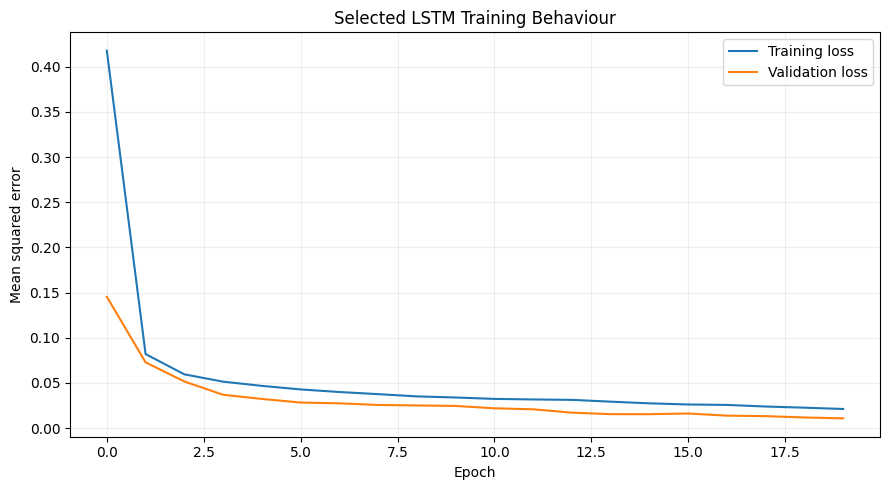

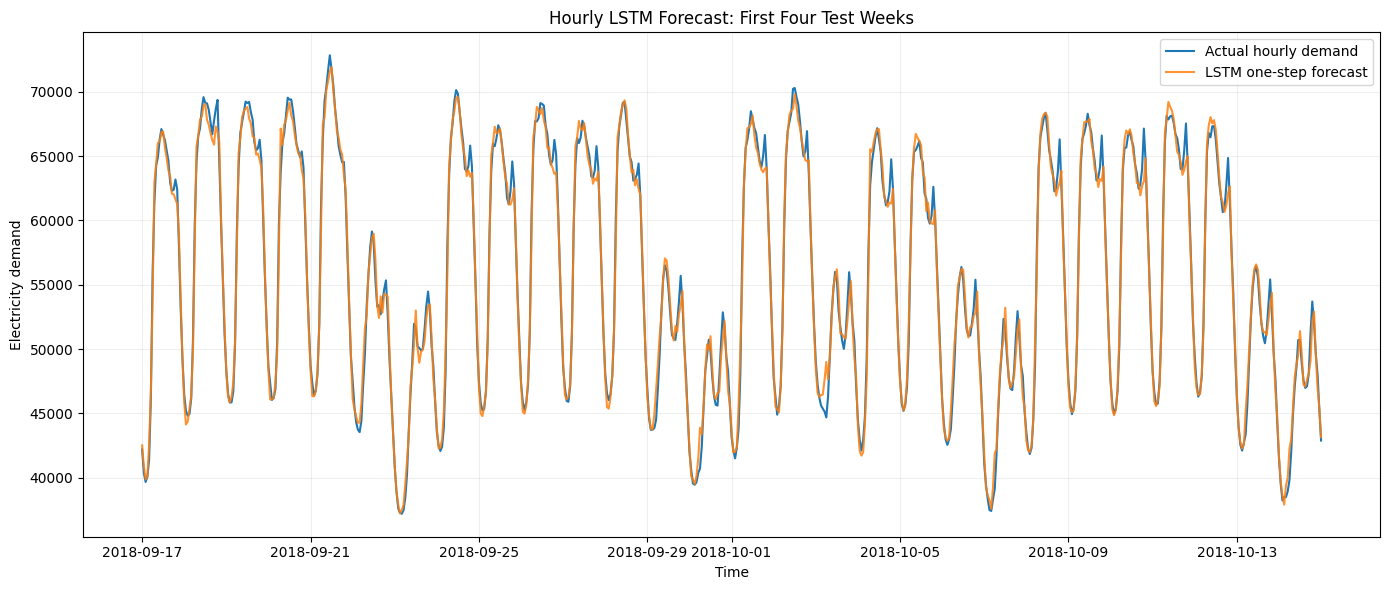

In [10]:
# ------------------------------------------------------------
# Part 6: Hourly LSTM
# Forecast type: rolling one-step-ahead evaluation
# ------------------------------------------------------------

sequence_length = 168

# The first test week begins six days before its Sunday label
hourly_test_start = (
    test.index.min() - pd.Timedelta(days=6)
).normalize()

pretest_hourly = hourly.loc[
    hourly.index < hourly_test_start
]

validation_start_position = int(
    len(pretest_hourly) * 0.80
)

validation_start_time = (
    pretest_hourly.index[
        validation_start_position
    ]
)

# Fit scaling only on the core training period
scaler = StandardScaler()

core_training_values = hourly.loc[
    hourly.index < validation_start_time
].to_numpy().reshape(-1, 1)

scaler.fit(core_training_values)

scaled_hourly = scaler.transform(
    hourly.to_numpy().reshape(-1, 1)
).ravel()

# Efficient sliding sequences
all_windows = np.lib.stride_tricks.sliding_window_view(
    scaled_hourly,
    sequence_length + 1
)

X_all = all_windows[:, :-1][..., np.newaxis].copy()
y_all = all_windows[:, -1].copy()

target_timestamps = hourly.index[sequence_length:]

training_mask = (
    target_timestamps < validation_start_time
)

validation_mask = (
    (target_timestamps >= validation_start_time) &
    (target_timestamps < hourly_test_start)
)

testing_mask = (
    target_timestamps >= hourly_test_start
)

X_lstm_train = X_all[training_mask]
y_lstm_train = y_all[training_mask]

X_lstm_validation = X_all[validation_mask]
y_lstm_validation = y_all[validation_mask]

X_lstm_test = X_all[testing_mask]
y_lstm_test = y_all[testing_mask]

test_hourly_index = target_timestamps[testing_mask]

print("LSTM training sequences:",
      X_lstm_train.shape)

print("LSTM validation sequences:",
      X_lstm_validation.shape)

print("LSTM testing sequences:",
      X_lstm_test.shape)


def build_lstm_model(
    first_units,
    second_units=None,
    dropout_rate=0.20,
    learning_rate=0.001
):
    """Create a single or stacked LSTM model."""
    model = Sequential()

    if second_units is None:
        model.add(
            LSTM(
                first_units,
                input_shape=(sequence_length, 1)
            )
        )
        model.add(Dropout(dropout_rate))

    else:
        model.add(
            LSTM(
                first_units,
                return_sequences=True,
                input_shape=(sequence_length, 1)
            )
        )
        model.add(Dropout(dropout_rate))
        model.add(LSTM(second_units))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


lstm_architectures = [
    {
        "name": "LSTM 32",
        "first_units": 32,
        "second_units": None,
        "dropout": 0.10,
        "learning_rate": 0.001
    },
    {
        "name": "LSTM 64",
        "first_units": 64,
        "second_units": None,
        "dropout": 0.20,
        "learning_rate": 0.001
    },
    {
        "name": "Stacked LSTM",
        "first_units": 64,
        "second_units": 32,
        "dropout": 0.20,
        "learning_rate": 0.0005
    }
]

lstm_tuning_results = []
best_validation_loss = np.inf
best_architecture = None
best_history = None
best_epoch_count = None

for architecture in lstm_architectures:
    tf.keras.backend.clear_session()

    model = build_lstm_model(
        first_units=architecture["first_units"],
        second_units=architecture["second_units"],
        dropout_rate=architecture["dropout"],
        learning_rate=architecture["learning_rate"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_lstm_train,
        y_lstm_train,
        validation_data=(
            X_lstm_validation,
            y_lstm_validation
        ),
        epochs=20,
        batch_size=256,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=1
    )

    minimum_validation_loss = min(
        history.history["val_loss"]
    )

    best_epoch = (
        np.argmin(history.history["val_loss"]) + 1
    )

    lstm_tuning_results.append({
        "Architecture": architecture["name"],
        "Minimum validation loss":
            minimum_validation_loss,
        "Best epoch": best_epoch
    })

    if minimum_validation_loss < best_validation_loss:
        best_validation_loss = minimum_validation_loss
        best_architecture = architecture
        best_history = history.history
        best_epoch_count = best_epoch

lstm_tuning_table = pd.DataFrame(
    lstm_tuning_results
).sort_values("Minimum validation loss")

print("\nLSTM architecture comparison")
display(lstm_tuning_table.round(6))

print("Selected architecture:",
      best_architecture["name"])

# Refit the selected architecture using all pre-test sequences
pretest_sequence_mask = (
    target_timestamps < hourly_test_start
)

X_lstm_pretest = X_all[pretest_sequence_mask]
y_lstm_pretest = y_all[pretest_sequence_mask]

tf.keras.backend.clear_session()

lstm_model = build_lstm_model(
    first_units=best_architecture["first_units"],
    second_units=best_architecture["second_units"],
    dropout_rate=best_architecture["dropout"],
    learning_rate=best_architecture["learning_rate"]
)

lstm_model.fit(
    X_lstm_pretest,
    y_lstm_pretest,
    epochs=best_epoch_count,
    batch_size=256,
    shuffle=False,
    verbose=1
)

lstm_scaled_prediction = (
    lstm_model
    .predict(
        X_lstm_test,
        batch_size=512,
        verbose=0
    )
    .ravel()
)

lstm_hourly_prediction = (
    scaler
    .inverse_transform(
        lstm_scaled_prediction.reshape(-1, 1)
    )
    .ravel()
)

lstm_hourly_actual = (
    scaler
    .inverse_transform(
        y_lstm_test.reshape(-1, 1)
    )
    .ravel()
)

hourly_rmse = np.sqrt(
    np.mean(
        (
            lstm_hourly_actual -
            lstm_hourly_prediction
        ) ** 2
    )
)

hourly_mae = np.mean(
    np.abs(
        lstm_hourly_actual -
        lstm_hourly_prediction
    )
)

hourly_smape = smape(
    lstm_hourly_actual,
    lstm_hourly_prediction
)

print("\nHourly LSTM evaluation")
print("MAE:", round(hourly_mae, 4))
print("RMSE:", round(hourly_rmse, 4))
print("sMAPE:", round(hourly_smape, 4))

# Aggregate hourly predictions to weekly means
lstm_hourly_series = pd.Series(
    lstm_hourly_prediction,
    index=test_hourly_index,
    name="LSTM prediction"
)

lstm_weekly_forecast = (
    lstm_hourly_series
    .resample("W-SUN")
    .mean()
    .reindex(test.index)
)

model_forecasts["LSTM"] = lstm_weekly_forecast

lstm_weekly_metrics = evaluate_forecast(
    "LSTM",
    test,
    lstm_weekly_forecast,
    train,
    train.iloc[-1]
)

print("\nWeekly aggregated LSTM evaluation")
display(
    pd.DataFrame([lstm_weekly_metrics]).round(4)
)

# Training history
plt.figure(figsize=(9, 5))

plt.plot(
    best_history["loss"],
    label="Training loss"
)

plt.plot(
    best_history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("Selected LSTM Training Behaviour")
plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

# Display the first four forecast weeks at hourly level
plot_end = test_hourly_index.min() + pd.Timedelta(
    days=28
)

hourly_plot_mask = test_hourly_index <= plot_end

plt.figure(figsize=(14, 6))

plt.plot(
    test_hourly_index[hourly_plot_mask],
    lstm_hourly_actual[hourly_plot_mask],
    label="Actual hourly demand"
)

plt.plot(
    test_hourly_index[hourly_plot_mask],
    lstm_hourly_prediction[hourly_plot_mask],
    label="LSTM one-step forecast",
    alpha=0.85
)

plt.title("Hourly LSTM Forecast: First Four Test Weeks")
plt.xlabel("Time")
plt.ylabel("Electricity demand")
plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

Complete model comparison


,Model,MAE,RMSE,sMAPE (%),MASE,Bias,Direction accuracy (%),Peak RMSE,Underforecast weeks,Mean shortfall,Maximum shortfall,Shortfall severity (%),Improvement over Seasonal Naive (%)
0,LSTM,156.3785,202.8228,0.2759,0.1014,-59.3133,95.1923,436.8648,55,203.9267,526.9593,0.1957,95.0328
1,CatBoost,1881.2060,2497.1856,3.5000,1.2197,1199.0358,61.5385,1618.3119,35,1013.5101,3722.9054,0.6188,38.8434
2,Seasonal Naive,3095.4679,4083.2661,5.6565,2.0069,1646.0845,49.0385,2653.1104,33,2283.8768,10845.8631,1.3148,0.0000
3,Drift,3635.2921,4278.7791,6.5954,2.3569,-273.5639,54.8077,7261.0008,51,3985.5002,8566.8220,3.5459,-4.7882
4,Naive,3720.8085,4353.4679,6.7510,2.4123,15.0489,55.7692,7139.2385,50,3853.9899,8467.8690,3.3617,-6.6173
5,Mean,3764.0674,4389.4842,6.8287,2.4404,561.3514,53.8462,6596.0176,47,3543.4304,7921.5665,2.9053,-7.4993
6,SARIMA,3508.5241,4578.9298,6.3511,2.2747,2598.3753,48.0769,2807.5257,25,1893.1095,8395.2919,0.8256,-12.1389
7,SARIMAX Temperature,3529.7408,4604.7944,6.3891,2.2885,2649.2611,48.0769,2763.0902,24,1907.7059,8282.9904,0.7987,-12.7723
8,SARIMAX Temperature + Holidays,5278.9062,6951.1819,9.3145,3.4225,5029.9008,56.7308,1367.2833,14,924.8772,3387.8630,0.2259,-70.2358


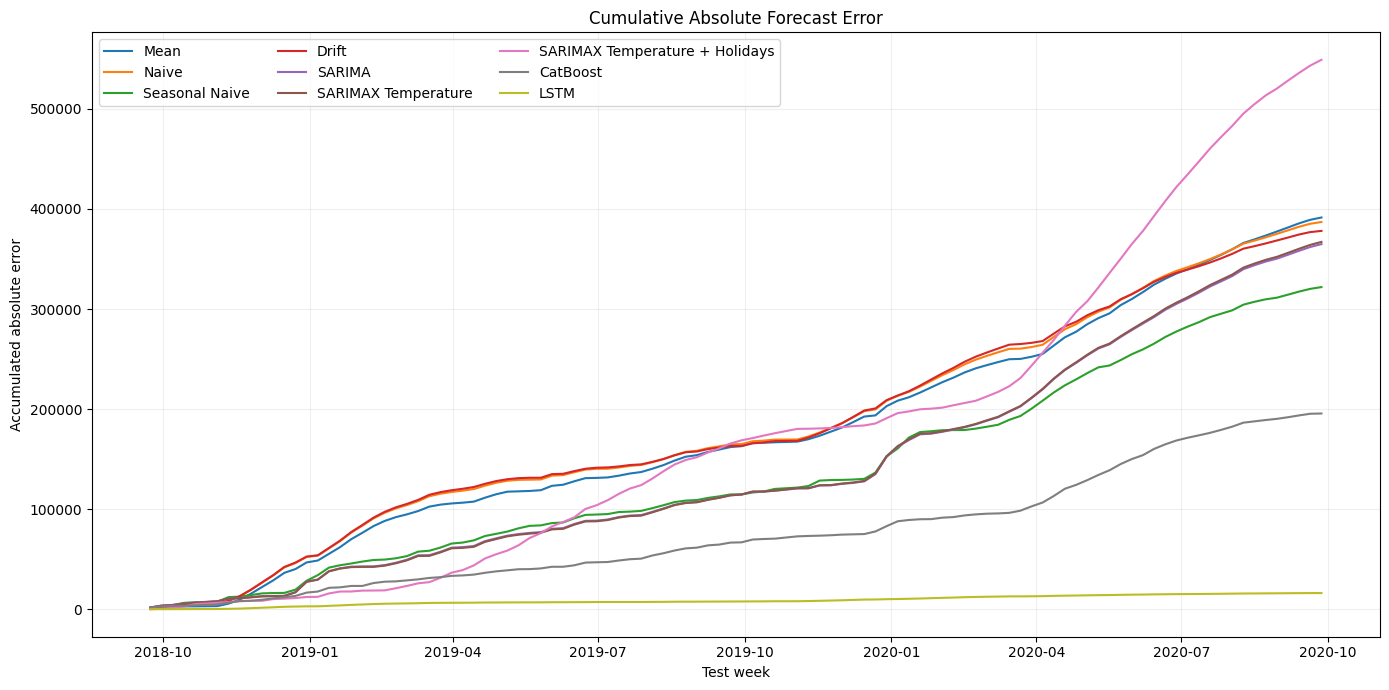

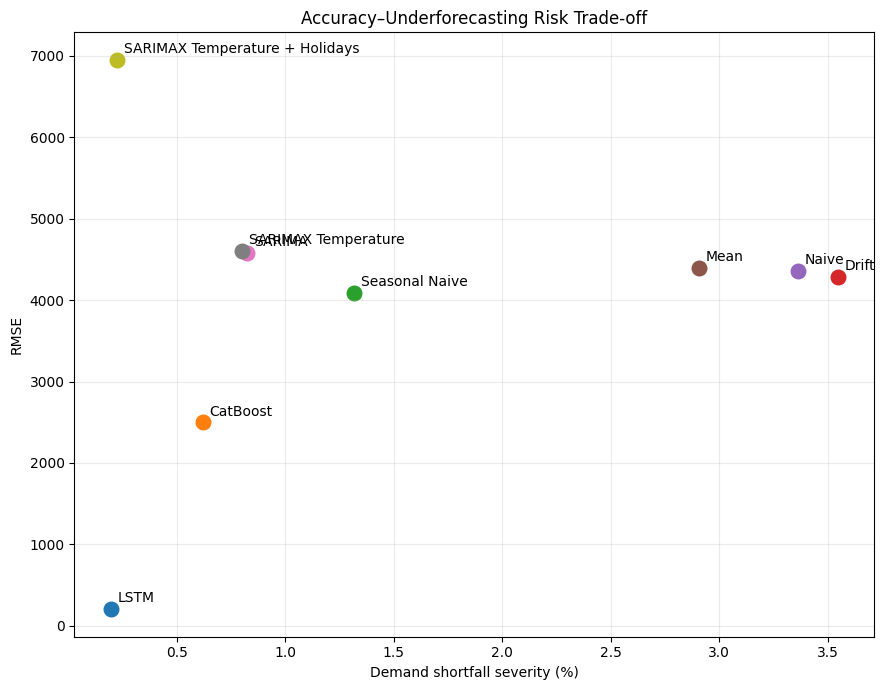

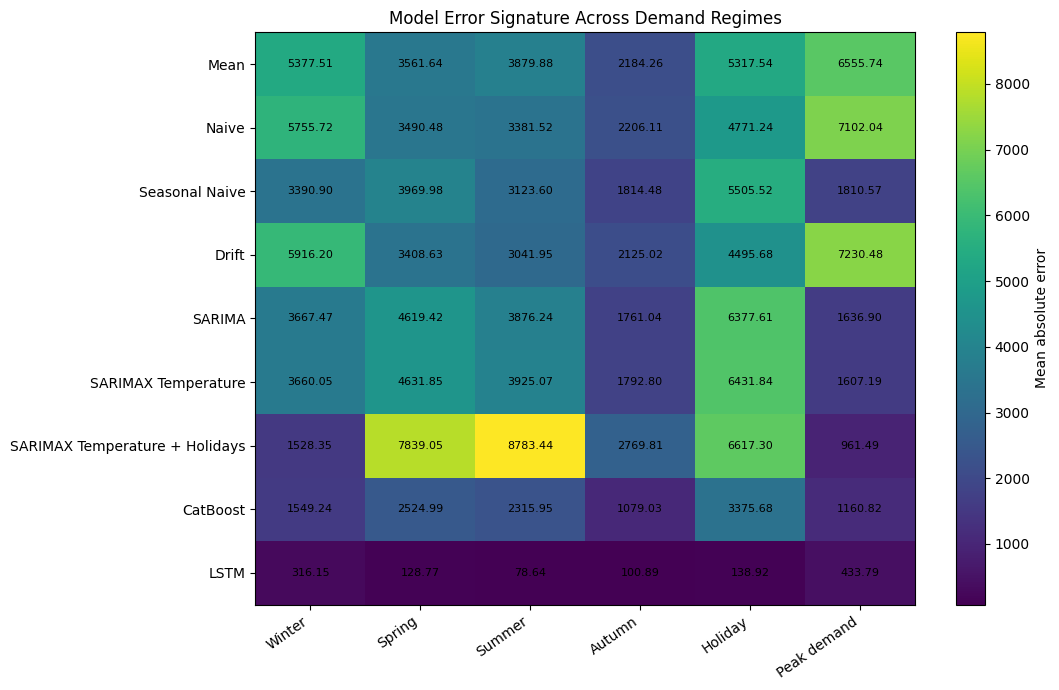


Prediction interval quality


,Model,Coverage (%),Mean interval width
0,SARIMA,69.2308,8844.4145
1,SARIMAX Temperature,78.8462,10679.4480
2,SARIMAX Temperature + Holidays,100.0000,25105.4490


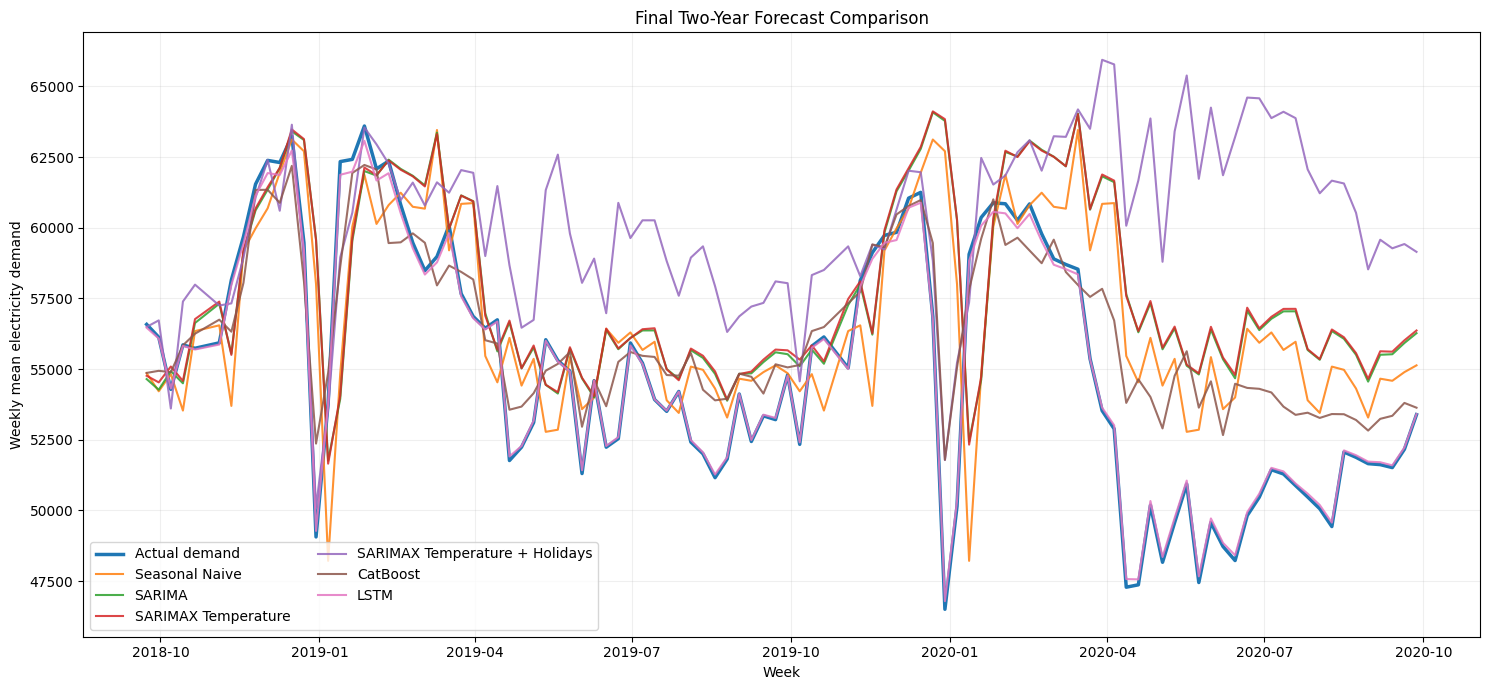

Lowest overall RMSE: LSTM
Lowest peak-week RMSE: LSTM
Lowest demand-shortfall severity: LSTM


In [11]:
# ------------------------------------------------------------
# Part 7: Unified comparison
# ------------------------------------------------------------

all_metric_rows = []

for model_name, forecast in model_forecasts.items():
    aligned_forecast = forecast.reindex(test.index)

    if aligned_forecast.isna().any():
        print(
            model_name,
            "contains missing forecast values and was excluded."
        )
        continue

    all_metric_rows.append(
        evaluate_forecast(
            model_name=model_name,
            actual=test,
            forecast=aligned_forecast,
            training_series=train,
            last_training_value=train.iloc[-1]
        )
    )

final_metrics = pd.DataFrame(all_metric_rows)

seasonal_naive_rmse = final_metrics.loc[
    final_metrics["Model"] == "Seasonal Naive",
    "RMSE"
].iloc[0]

final_metrics["Improvement over Seasonal Naive (%)"] = (
    (
        seasonal_naive_rmse -
        final_metrics["RMSE"]
    ) /
    seasonal_naive_rmse
) * 100

final_metrics = final_metrics.sort_values(
    "RMSE"
).reset_index(drop=True)

print("Complete model comparison")
display(final_metrics.round(4))

# ------------------------------------------------------------
# Evaluation plot 1:
# Cumulative error shows when models lose accuracy
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

for model_name, forecast in model_forecasts.items():
    forecast = forecast.reindex(test.index)

    if forecast.isna().any():
        continue

    cumulative_error = (
        np.abs(test - forecast)
        .cumsum()
    )

    plt.plot(
        test.index,
        cumulative_error,
        label=model_name
    )

plt.title("Cumulative Absolute Forecast Error")
plt.xlabel("Test week")
plt.ylabel("Accumulated absolute error")
plt.legend(ncol=3)
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Evaluation plot 2:
# Accuracy versus operational underforecasting risk
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

for _, row in final_metrics.iterrows():
    plt.scatter(
        row["Shortfall severity (%)"],
        row["RMSE"],
        s=110
    )

    plt.annotate(
        row["Model"],
        (
            row["Shortfall severity (%)"],
            row["RMSE"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Demand shortfall severity (%)")
plt.ylabel("RMSE")
plt.title("Accuracy–Underforecasting Risk Trade-off")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Evaluation plot 3:
# Error signature across operational regimes
# ------------------------------------------------------------

test_information = weekly_exog.loc[
    test.index
].copy()

test_information["season"] = np.select(
    [
        test_information.index.month.isin(
            [12, 1, 2]
        ),
        test_information.index.month.isin(
            [3, 4, 5]
        ),
        test_information.index.month.isin(
            [6, 7, 8]
        )
    ],
    [
        "Winter",
        "Spring",
        "Summer"
    ],
    default="Autumn"
)

peak_mask = test >= test.quantile(0.90)
holiday_mask = (
    test_information["holiday_days"] > 0
)

regime_masks = {
    "Winter": (
        test_information["season"] == "Winter"
    ).to_numpy(),
    "Spring": (
        test_information["season"] == "Spring"
    ).to_numpy(),
    "Summer": (
        test_information["season"] == "Summer"
    ).to_numpy(),
    "Autumn": (
        test_information["season"] == "Autumn"
    ).to_numpy(),
    "Holiday": holiday_mask.to_numpy(),
    "Peak demand": peak_mask.to_numpy()
}

error_signature_rows = []

for model_name, forecast in model_forecasts.items():
    forecast = forecast.reindex(test.index)

    if forecast.isna().any():
        continue

    row = {"Model": model_name}

    for regime_name, mask in regime_masks.items():
        if mask.sum() == 0:
            row[regime_name] = np.nan
        else:
            row[regime_name] = np.mean(
                np.abs(
                    test.to_numpy()[mask] -
                    forecast.to_numpy()[mask]
                )
            )

    error_signature_rows.append(row)

error_signature = (
    pd.DataFrame(error_signature_rows)
    .set_index("Model")
)

plt.figure(figsize=(11, 7))

heatmap = plt.imshow(
    error_signature,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    heatmap,
    label="Mean absolute error"
)

plt.xticks(
    range(len(error_signature.columns)),
    error_signature.columns,
    rotation=35,
    ha="right"
)

plt.yticks(
    range(len(error_signature.index)),
    error_signature.index
)

for row_position in range(
    len(error_signature.index)
):
    for column_position in range(
        len(error_signature.columns)
    ):
        value = error_signature.iloc[
            row_position,
            column_position
        ]

        plt.text(
            column_position,
            row_position,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Model Error Signature Across Demand Regimes")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Prediction interval evaluation
# ------------------------------------------------------------

interval_rows = []

for model_name, interval_values in (
    model_intervals.items()
):
    lower, upper = interval_values

    interval_result = interval_evaluation(
        test,
        lower,
        upper
    )

    interval_rows.append({
        "Model": model_name,
        **interval_result
    })

interval_metrics = pd.DataFrame(interval_rows)

print("\nPrediction interval quality")
display(interval_metrics.round(4))

# ------------------------------------------------------------
# Final all-model forecast plot
# ------------------------------------------------------------

selected_plot_models = [
    "Seasonal Naive",
    "SARIMA",
    "SARIMAX Temperature",
    "SARIMAX Temperature + Holidays",
    "CatBoost",
    "LSTM"
]

plt.figure(figsize=(15, 7))

plt.plot(
    test.index,
    test,
    label="Actual demand",
    linewidth=2.5
)

for model_name in selected_plot_models:
    if model_name in model_forecasts:
        plt.plot(
            test.index,
            model_forecasts[
                model_name
            ].reindex(test.index),
            label=model_name,
            alpha=0.85
        )

plt.title("Final Two-Year Forecast Comparison")
plt.xlabel("Week")
plt.ylabel("Weekly mean electricity demand")
plt.legend(ncol=2)
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

# Automatic evidence-based summary
best_accuracy_model = final_metrics.iloc[0]["Model"]

best_peak_model = (
    final_metrics
    .sort_values("Peak RMSE")
    .iloc[0]["Model"]
)

lowest_shortfall_model = (
    final_metrics
    .sort_values("Shortfall severity (%)")
    .iloc[0]["Model"]
)

print("Lowest overall RMSE:", best_accuracy_model)
print("Lowest peak-week RMSE:", best_peak_model)
print("Lowest demand-shortfall severity:",
      lowest_shortfall_model)